# 09 — Prepare Descriptors for Complex Phase Prediction

Prepares BOP, ACE, and SOAP descriptors for all configurations of the complex TCP phases (R, M, P, δ) to be used in the prediction notebooks.

## Prerequisites / Input files
- `Fe-Mo/Atomsobjects/{R,M,P,delta}_structures.pkl` — structure objects (available on Zenodo)
- `Fe-Mo/Descriptors/PREDICTION_Fe-Mo_{R,M,P,delta}_0.7dprojections_0.5os_table_WUBIND_16.pkl` — pre-computed BOP descriptors (available on Zenodo)

## Outputs
- `Fe-Mo/Descriptors/CNAV_PREDICTION_Fe-Mo_*.pkl` — coordination-averaged prediction descriptors

## Notes
> Pre-computed BOP descriptors for the complex phases are provided in the Zenodo archive. Download them before running this notebook.

> ACE and SOAP descriptors for complex phases can be recomputed if `python-ace` and DScribe are available.



# Prepare the structures and the features for R, P, M and $\delta$ phases

In [1]:
from Tools.DatasetTools.Commoms import *
from Tools.DatasetTools import GeneralFeaturizer as gf
from Tools.DatasetTools.DatasetOperator import Dataset
from Tools.PredictionTools.MakeAtomsOjects import make_all_atoms_objects, permutate, old_permutate
import joblib
try:
    from dependencies.bopdftprojections.bopdftprojections.projections import Projections
    _has_bopdftprojection = True
except (ModuleNotFoundError, ImportError):
    _has_bopdftprojection = False
from Tools import PlottingTools as plotting
from Tools.DatasetTools.GeneralFeaturizer import cn_persite
from importlib.machinery import SourceFileLoader
from sklearn.metrics import mean_squared_error
import logging
dataset = 'Fe-Mo' #'Cr-Co-W'
NameForFile = 'FeMo'
MAG = 0
if MAG == 0:
    target_case = 'EF_nmhcp'
    mag_tag = 'NM'
elif MAG == 1:
    target_case = 'EF_fmbcc'
    mag_tag = 'FM'

descriptorlocation = os.path.join(dataset, 'Descriptors')
system = dataset.replace('-','')

/home/mariano/.local/micromamba/envs/Test_MLFeMoTCPs/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
logger = logging.getLogger()
logging.basicConfig( format='%(message)s',level=logging.INFO,)


In [3]:
import shutil

# Enable LaTeX text rendering only if a TeX Live toolchain is available.
required_tex_bins = ("latex", "dvipng", "kpsewhich")
has_texlive = all(shutil.which(cmd) is not None for cmd in required_tex_bins)

plt.rc("text", usetex=has_texlive)
plt.rc("font", family="serif", size=24)
plt.rc("xtick", labelsize=18)
plt.rc("ytick", labelsize=18)
plt.rc("axes", labelsize=18)
figw, figh = plt.rcParams['figure.figsize']

if not has_texlive:
    print(
        "TeX Live not fully available (missing one of: latex, dvipng, kpsewhich). "
        "Using matplotlib internal text rendering."
    )

In [4]:
import logging

In [5]:
from mendeleev import element
from ase import Atoms

In [6]:
import Tools.PredictionTools.MakeAtomsOjects as MAO

In [7]:
skip_vis = os.getenv("SKIP_VIS", "").strip().lower() in {"1", "true", "yes", "on"}

In [8]:
BOP = '0.7dProjections_0.5os'
Bop = '0.7dprojections_0.5os'
ACE = 'ACE'
SOAPlabel = 'SOAP_specific_small'
Soap = 'SOAP'
ModelName = 'Kernel Ridge'
FeatureLabels = {BOP: 'BOP', ACE: 'ACE', SOAPlabel : 'SOAP', Bop: 'BOP', Soap: 'SOAP'}
TrainingNames = {BOP: '0.7dProjections 0.5OS BOP', ACE: 'ACE', SOAPlabel: 'SOAP_specific_small'}

In [9]:
DS = Dataset(dataset=dataset, target_name=target_case, remove_phases_query='Phase != "bcc" and Phase != "fcc" and Phase !="hcp"')
BS = DS.BS #pd.read_pickle(f'{dataset}/FullyCuratedParsedBriefSummary.pkl')
BS = BS.loc[~BS.index.str.contains('delta')]
TRAIN_RBS = BS.query('Phase == "R"')

In [10]:
samplesplit = DS.get_samplesplit()

In [11]:
samplesplit['train']

Index(['Fe_pv10Mo_sv2.C14-ABA.NM', 'Mo_sv53.R.NM', 'Fe_pv6Mo_sv6.C14-AAB.FM',
       'Fe_pv33Mo_sv20.R-AAAAAAABBBB.NM', 'Fe_pv14Mo_sv10.C36-ABABA.FM',
       'Fe_pv14Mo_sv10.C36-ABAAB.NM', 'Fe_pv25Mo_sv4.chi-ABAA.FM',
       'Fe_pv2Mo_sv6.A15-BA.FM', 'Fe_pv50Mo_sv3.R-BBAAAAAAAAA.NM',
       'Fe_pv12Mo_sv12.C36-BBBAA.NM',
       ...
       'Fe_pv1Mo_sv12.mu-ABBBB.NM', 'Fe_pv6Mo_sv2.A15-AB.NM',
       'Fe_pv16Mo_sv13.chi-BABA.NM', 'Fe_pv10Mo_sv14.C36-BABBA.NM',
       'Fe_pv1Mo_sv28.chi-ABBB.NM', 'Fe_pv52Mo_sv1.R-BAAAAAAAAAA.NM',
       'Fe_pv2Mo_sv11.mu-BBBBA.NM', 'Fe_pv8Mo_sv4.C14-BAA.FM',
       'Fe_pv5Mo_sv24.chi-AABB.FM', 'Fe_pv8Mo_sv16.C36-AABBB.NM'],
      dtype='object', length=209)

In [12]:
BS.filter(regex = "EF")

,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv4Mo_sv20.C36-ABBBB.FM,0.478663,0.478663,0.478663
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,0.154058,0.133919,0.111544
Fe_pv2Mo_sv11.mu-BBABB.FM,0.403272,0.403272,0.403272
Fe_pv8Mo_sv22.sigma-BBBAB.NM,0.077265,0.058290,0.037208
Fe_pv2Mo_sv11.mu-BBBBA.NM,0.374554,0.363607,0.351444
...,...,...,...
Fe_pv30.sigma.FM,0.075258,0.075258,0.075258
Fe_pv6.C15.FM,0.144169,0.144169,0.144169
Mo_sv8.A15.NM,0.095306,0.095306,0.095306
Mo_sv6.C15.NM,0.367463,0.367463,0.367463


In [13]:
target_case

'EF_nmhcp'

In [14]:
DS.StructureNames[DS.StructureNames == 'M']

Series([], Name: Phase, dtype: object)

In [15]:
train_features = DS.Features

In [16]:
train_features['atomic']['Structure'].max()

10

In [17]:
train_features['atomic']['Structure'].min()

0

In [18]:
pd.concat([ DS.StructureNames, train_features['atomic']['Structure']], axis =1 ).reset_index(drop=True).drop_duplicates().sort_values('Structure')

,Phase,Structure
179,A15,0
6,C14,1
178,C15,2
0,C36,3
1,R,4
11,chi,6
2,mu,9
3,sigma,10


In [19]:
CNListLocation = os.path.join(descriptorlocation,'CNList.pkl')
CNList = pd.read_pickle(CNListLocation)

In [20]:
LearningAtomsObjects = pd.read_json('Fe-Mo/Atomsobjects/Fe-Mo-POSCAR.initial-rescaled-AtomsObjects.json').query('index.str.contains("R-.*NM$")')
LearningAtomsObjects['atoms'] = LearningAtomsObjects['atoms'].map(Atoms.fromdict)

In [21]:
AtomsObjects = {'R' :
#                        {'permutations': LearningAtomsObjects.index.str.split('\.').map(lambda s: s[1]),
#                         'atoms_objects_file': os.path.join(dataset,'Atomsobjects/R_structures.pkl')}
                    {'permutations': permutate('R', 2, 11), 'atoms_objects_file': os.path.join(dataset,'Atomsobjects/R_structures.pkl')}, 
#                    'R_old':
#                    {'permutations': old_permutate('R', 2, 11), 'atoms_objects_file': os.path.join(dataset, 'Atomsobjects/R_structures_old.pkl')},
                    'P' : 
                    {'permutations': permutate('P', 2, 12), 'atoms_objects_file': os.path.join(dataset,'Atomsobjects/P_structures.pkl')},
#                    'P_old' : 
#                    {'permutations': old_permutate('P', 2, 12), 'atoms_objects_file': os.path.join(dataset,'Atomsobjects/P_structures.pkl')},
                    'delta': 
                    {'permutations': permutate('delta', 2, 14), 'atoms_objects_file' : os.path.join(dataset,'Atomsobjects/delta_structures.pkl') },
                    'M':
                    {'permutations': permutate('M', 2, 11 ), 'atoms_objects_file': os.path.join(dataset,'Atomsobjects', 'M_structures.pkl' )}
                   }

In [22]:
AtomsObjects['R']['permutations'][0], AtomsObjects['R']['permutations'][-1], 

('R-AAAAAAAAAAA', 'R-BBBBBBBBBBB')

In [23]:
atom_volumes = {'Fe': 11.734084234678496, 'Mo': 15.89162790660502}

In [24]:
#atom_volumes = MAO.get_atom_volume_from_mp({'Fe' : 'mp-13', 'Mo' : 'mp-129'})
# was taking volumes from MP , but MPRester is not working due to incompatibilities

In [25]:
atom_volumes

{'Fe': 11.734084234678496, 'Mo': 15.89162790660502}

In [26]:
for phase, phase_atoms in AtomsObjects.items():
    if os.path.exists(phase_atoms['atoms_objects_file']):
        logger.info(f'Reading {phase} atoms objects from {phase_atoms["atoms_objects_file"]}')
        phase_atoms['Atoms'] = pd.read_pickle(phase_atoms['atoms_objects_file'])
    else:
        logger.info(f'Generating atoms for  {phase}')
        phase_atoms['Atoms'] = make_all_atoms_objects(phase_atoms['permutations'], atom_volumes_def=atom_volumes)
        phase_atoms['Atoms'] = phase_atoms['Atoms'].to_frame()
        phase_atoms['Atoms'].index = phase_atoms['Atoms'].index +f'.{mag_tag}'
        phase_atoms['Atoms'].columns = ['atoms']
        phase_atoms['Atoms'].to_pickle(phase_atoms['atoms_objects_file'])
        logger.info(f'Saved {len(phase_atoms["Atoms"])} for phase {phase} in { phase_atoms["atoms_objects_file"] }')
AtomsObjects['R']['Atoms'].index = AtomsObjects['R']['Atoms'].index.str.replace("-AAAAAAAAAAA", '')
AtomsObjects['R']['Atoms'].index = AtomsObjects['R']['Atoms'].index.str.replace("-BBBBBBBBBBB", '')

Reading R atoms objects from Fe-Mo/Atomsobjects/R_structures.pkl
Reading P atoms objects from Fe-Mo/Atomsobjects/P_structures.pkl
Reading delta atoms objects from Fe-Mo/Atomsobjects/delta_structures.pkl
Reading M atoms objects from Fe-Mo/Atomsobjects/M_structures.pkl


In [27]:
AtomsObjects['R']['Atoms']

,atoms
Fe_pv53.R.NM,"(Atom('Fe', [5.614366370550564, 5.130930694031..."
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM,"(Atom('Fe', [5.688450365423163, 5.198635545859..."
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM,"(Atom('Fe', [5.63927762944244, 5.1536969216767..."
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM,"(Atom('Fe', [5.712721111029581, 5.220816412832..."
Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM,"(Atom('Fe', [5.688450365423163, 5.198635545859..."
...,...
Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM,"(Atom('Mo', [6.149712932802712, 5.620180224060..."
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM,"(Atom('Mo', [6.12878666841063, 5.6010558553976..."
Fe_pv2Mo_sv51.R-BBBBBBBBBAB.NM,"(Atom('Mo', [6.191143463482836, 5.658043300231..."
Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM,"(Atom('Mo', [6.149712932802712, 5.620180224060..."


## compare atoms objects to the ones used for learning

Text(0.5, 0, 'volume of unit cell in training set')

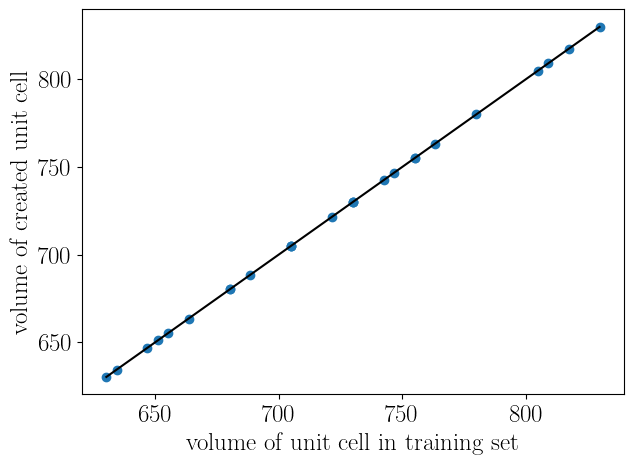

In [28]:
not_created = AtomsObjects['R']['Atoms'].index.difference(LearningAtomsObjects.index)

intersection = LearningAtomsObjects.index.intersection(AtomsObjects['R']['Atoms'].index)

created_intersection_volumes = AtomsObjects['R']['Atoms'].atoms[intersection].map(lambda a: a.get_volume())

#alt_created_intersection_volumes = binaries_predict['R_old']['Atoms'].atoms[intersection].map(lambda a: a.get_volume())


intersection_volumes = LearningAtomsObjects.atoms[intersection].map(lambda a: a.get_volume())

fig, axes = plt.subplots()
axes.scatter(intersection_volumes, created_intersection_volumes)
#axes.scatter(intersection_volumes, alt_created_intersection_volumes)
axes.plot([ created_intersection_volumes.min(), created_intersection_volumes.max() ], [ created_intersection_volumes.min(), created_intersection_volumes.max() ], '-k')
axes.set_ylabel('volume of created unit cell')
axes.set_xlabel('volume of unit cell in training set')

In [29]:
if not skip_vis:
    theatoms = AtomsObjects['P']['Atoms'].atoms.sample(n=1).iloc[0]
    plotting.plotly_atoms(theatoms)

In [30]:
if not skip_vis:
    theatoms = AtomsObjects['R']['Atoms'].atoms.sample(n=1).iloc[0]
    plotting.plotly_atoms(theatoms)

In [31]:
if not skip_vis:
    theatoms = AtomsObjects['delta']['Atoms'].atoms.sample(n=1).iloc[0]
    plotting.plotly_atoms(theatoms)

In [32]:
if not skip_vis:
    theatoms = AtomsObjects['M']['Atoms'].atoms.sample(n=1).iloc[0]
    plotting.plotly_atoms(theatoms)

# Generate Prediction samples 

In [33]:
def get_nelem(a):
    return len(np.unique(a.get_chemical_symbols()))

In [34]:
BS_predict = {}
for phase, phaseAtoms in AtomsObjects.items():
    logger.info(f'Training data for {phase}')
    BS_predict[phase] = phaseAtoms['Atoms'].atoms.map(len)
    BS_predict[phase].name = 'num_atoms'
    compo = pd.DataFrame.from_dict(
        phaseAtoms['Atoms'].atoms.map(lambda a: pd.Series(a.symbols).value_counts().to_dict()).to_dict(),
        orient = 'index'
    ).fillna(0)
    compo['Fe_pv'] = compo['Fe'] / BS_predict[phase]
    compo['Mo_sv'] = 1 - compo['Fe_pv']
    compo['Mag'] = MAG #FM
    compo['nelem'] = phaseAtoms['Atoms'].atoms.map(get_nelem)
    BS_predict[phase] = pd.concat([BS_predict[phase], compo], axis = 1)

Training data for R
Training data for P
Training data for delta
Training data for M


In [35]:
BS_predict['R']['Structure'] = 4
#BS_predict['R_old']['Structure'] = 4
BS_predict['P']['Structure'] = 11
BS_predict['delta']['Structure'] = 11
BS_predict['M']['Structure'] = 11

In [36]:
BS[BS['Phase'] == "R"]

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,bulk R-AAAABBBBBBB,14.436090 A,-10.020954,255.953497 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,...,15,38,53,0.283019,0.716981,NM,R,0.154058,0.133919,0.111544
Fe_pv9Mo_sv44.R-AAABBBBBBBB.NM,bulk R-AAABBBBBBBB,15.195143 A,-10.255394,247.124292 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,...,9,44,53,0.169811,0.830189,NM,R,0.222742,0.210658,0.197233
Fe_pv3Mo_sv50.R-AABBBBBBBBB.NM,bulk R-AABBBBBBBBB,15.948587 A,-10.493489,240.778599 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,...,3,50,53,0.056604,0.943396,NM,R,0.287770,0.283743,0.279267
Fe_pv1Mo_sv52.R-ABBBBBBBBBB.NM,bulk R-ABBBBBBBBBB,16.207674 A,-10.574992,238.852230 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,...,1,52,53,0.018868,0.981132,NM,R,0.307309,0.305966,0.304474
Mo_sv53.R.NM,bulk R,16.315439 A,-10.625314,238.808096 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,1,...,53,0,53,0.000000,1.000000,NM,R,0.307507,0.307507,0.307507
Fe_pv53.R.NM,bulk R,10.496832 A,-8.018508,274.081057 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,1,...,53,0,53,1.000000,0.000000,NM,R,0.236720,0.165564,0.086503
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM,bulk R-AAAAAAAAABA,10.670060 A,-8.146282,274.796406 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,...,51,2,53,0.962264,0.037736,NM,R,0.209987,0.141516,0.065439
Fe_pv50Mo_sv3.R-BBAAAAAAAAA.NM,bulk R-BBAAAAAAAAA,10.804051 A,-8.176541,271.783619 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,...,50,3,53,0.943396,0.056604,NM,R,0.230249,0.163120,0.088535
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM,bulk R-AAAAAAAAAAB,11.000617 A,-8.413097,277.323503 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,...,47,6,53,0.886792,0.113208,NM,R,0.145255,0.082154,0.012044
Fe_pv46Mo_sv7.R-BAAAAAABAAA.NM,bulk R-BAAAAAABAAA,11.210107 A,-8.416749,269.958521 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,...,46,7,53,0.867925,0.132075,NM,R,0.192123,0.130365,0.061747


# LOAD MODELS 

In [37]:
regressor_file = os.path.join(dataset, 'results', f'voting_regressor_KernelRidge.pkl')
from Tools.DatasetTools.MLConveniences import filter_features
voting_regressor = joblib.load(regressor_file)

# Recover learning predictions

In [38]:
FeaturesOfInterest = [BOP, ACE, SOAPlabel]

In [39]:
Learning_Predictions = {}
for featurename in FeaturesOfInterest:
    X = DS.Features[TrainingNames[featurename]]#.query('Mag == 0')
    Y = DS.target#[X.index]
    intersection = X.index.intersection(Y.index)
    x = X.loc[intersection].astype(float)
    y = Y.loc[intersection].astype(float)
    #voting_regressor[('Kernel Ridge', TrainingNames[featurename] )].fit(X.astype(float), Y)
    try:
        Learning_Predictions[featurename] = voting_regressor[(ModelName, TrainingNames[featurename])].predict(x)#()#DS.Features
        Learning_Predictions[featurename] = pd.Series(Learning_Predictions[featurename], index = x.index, name = target_case+f'__{featurename}')
    except:
        voting_regressor[('Kernel Ridge', TrainingNames[featurename] )].fit(x, y)
        Learning_Predictions[featurename] = voting_regressor[(ModelName, TrainingNames[featurename])].predict(x)#()#DS.Features
        Learning_Predictions[featurename] = pd.Series(Learning_Predictions[featurename], index = x.index, name = target_case+f'__{featurename}')

In [40]:
LearningRPhase = BS[BS['Phase']=='R'].index

In [41]:
Learning_Predictions.keys()

dict_keys(['0.7dProjections_0.5os', 'ACE', 'SOAP_specific_small'])

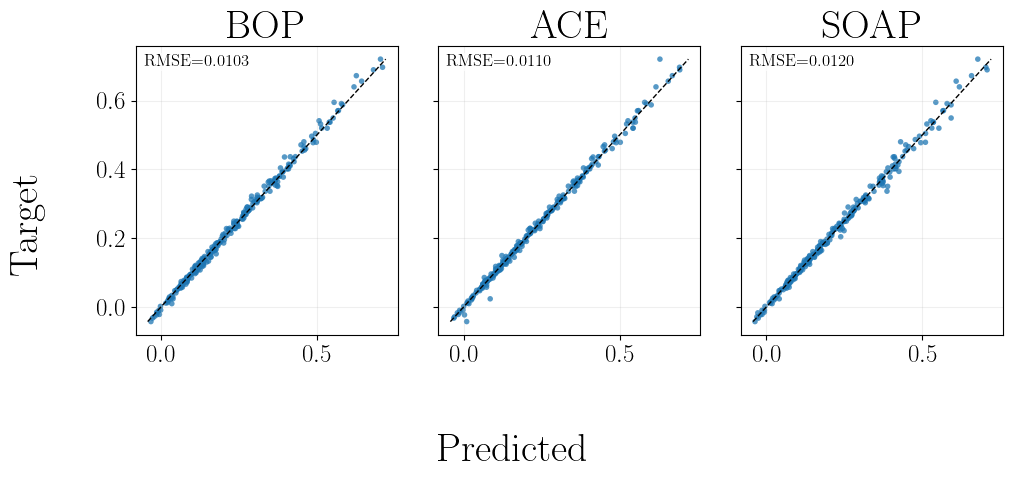

In [42]:
n_panels = len(Learning_Predictions)
ncols = min(3, n_panels)
nrows = int(np.ceil(n_panels / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(figw * ncols/2, figh  * nrows),
    squeeze=False,
    sharex=True,
    sharey=True,
)

for ax, (featurename, pred_series) in zip(axes.ravel(), Learning_Predictions.items()):
    common_idx = pred_series.index.intersection(DS.target.index)
    x = pred_series.loc[common_idx]
    y = DS.target.loc[common_idx]

    ax.scatter(x, y, s=16, alpha=0.75, edgecolor='none')

    vmin = min(x.min(), y.min())
    vmax = max(x.max(), y.max())
    ax.plot([vmin, vmax], [vmin, vmax], '--k', lw=1.0)

    rmse = mean_squared_error(y.values, x.values, squared=False) #np.sqrt(np.mean((y.values - x.values) ** 2))
    ax.text(
        0.03, 0.97,
        f'RMSE={rmse:.4f}',
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=12,
        bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.5),
    )

    ax.set_title(FeatureLabels[featurename])
    ax.grid(alpha=0.2)

# Hide unused axes if grid is larger than the number of panels.
for ax in axes.ravel()[n_panels:]:
    ax.set_visible(False)

fig.supxlabel('Predicted')
fig.supylabel('Target')
fig.tight_layout()

# CALCULATE FEATURES 

In [43]:
import shutil

In [44]:
elements = dataset.split('-')

## BOP Features 

In [45]:
from BopFoxFeaturizer.Featurizer import BopfoxFeatures
print("bopfoxfeaturizer import OK")
from Tools.DatasetTools.Commoms import *
cwd = os.getcwd()
bopfox_binary = os.path.join(cwd, 'dependencies', 'bopfox','src', 'bopfox')
if os.path.exists(bopfox_binary):
    _has_bopfox = True
    os.environ['PATH']+=':'+os.path.dirname(bopfox_binary)
from BopFoxFeaturizer.Featurizer import Featurizer, BopfoxFeatures

bopfoxfeaturizer import OK


### Define parameters for BOP

In [46]:
DS.Features.keys()

dict_keys(['atomic', 'dataset', 'SOAP_specific_small', 'ACE', 'Canonical ACE', 'Canonical BOP', '0.7dProjections 0.5OS BOP', 'dataset + Canonical BOP', 'dataset + 0.7dProjections 0.5OS BOP', 'atomic no CNAV', 'dataset no CNAV', 'SOAP_specific_small no CNAV', 'ACE no CNAV', 'Canonical ACE no CNAV', 'Canonical BOP no CNAV', '0.7dProjections 0.5OS BOP no CNAV', 'dataset + Canonical BOP no CNAV', 'dataset + 0.7dProjections 0.5OS BOP no CNAV'])

In [47]:
globalmoments = 16
model_definitions = {
    '0.7dprojections_0.5os': {'model_maker_options' : {
        'element_pairs_kwargs' : {
            'bond_integral_scale': 0.7,
        },
        'atom_blocks_kwargs': {
            'onsite_levels_scale' : 0.5,
            'select_orbitals' : {'Fe': 'd', 'Mo' : 'd'}
        },
    },
    'moments' : globalmoments
    },
}
cutoff = 'table'
atoms = ['initial', 'relaxed']
retry = False

In [48]:
if _has_bopdftprojection:
    P = Projections()
    P.readbxmodels()
    P.get_bond_chunks()
    P.get_autobonds()
    P.get_all_onsite_levels()
    P.get_restructured_projections()
    def create_modelfile(acompound, target_model_filename, modelname='projections', element_pairs_kwargs={}, atom_blocks_kwargs={} ):
        print(acompound)
        if 'canonical' not in modelname :
            model_filename = P.save_abond_bx(acompound, return_filename=True,
                                            modelname=modelname, 
                                            element_pairs_kwargs=element_pairs_kwargs,
                                            atom_blocks_kwargs=atom_blocks_kwargs)
            print(model_filename)
        else:
            model_filename = C.base_canonical #f'models/W_canonical.bx'
        shutil.copy(model_filename, target_model_filename)
    def replace_symbols(theatoms, replacements=None):
        new_symbols = theatoms.get_chemical_symbols()
        if replacements is not None:
            for original, replacement in replacements.items():
                new_symbols = [s.replace(original, replacement) for s in new_symbols]
        new_atoms = theatoms.copy()
        new_atoms.set_chemical_symbols(new_symbols)
        return new_atoms


### Calculate or load precalculated BOP features

In [49]:
bop_features = {}
bop_features_files = {}

In [50]:
for (model, definition), (phase, atoms_df) in product(model_definitions.items(), AtomsObjects.items()):
    if _has_bopdftprojection:
        if 'moments' in definition.keys():
            thismoments = definition['moments']
        else:
            thismoments = 16
        if (model, thismoments, phase) in bop_features.keys():
            continue
        create_model_options = {}
        if 'model_maker_options' in definition.keys():
            create_model_options.update(definition['model_maker_options'])
    use_elements = copy.copy(elements)
    if _has_bopdftprojection:
        if 'replace atoms' in definition.keys():
            for realelement, targetelement in definition['replace atoms'].items():
                use_elements = set([s.replace(realelement, targetelement) for s in use_elements])
    components = ''.join(use_elements)
    if _has_bopdftprojection:
        modelsfile = os.path.join('models', f'{dataset}-{components}_{model}.bx')
        if not os.path.exists(os.path.dirname(modelsfile)):
            os.makedirs(os.path.dirname(modelsfile))
        create_modelfile(use_elements,modelsfile, modelname=model, **create_model_options,   )
        if 'replace atoms' in definition.keys():
            ApplyOnAtoms = atoms_df['atoms'].apply(replace_symbols, replacements = definition['replace atoms'])
        else:
            ApplyOnAtoms = atoms_df.atoms

    logger.info(f'atoms: , { phase } model:  { model },  cutoff: , { cutoff },  moments:, { globalmoments }')
    bop_features_files[(model, phase)] = os.path.join(dataset, 'Descriptors', f'PREDICTION_{dataset}_{phase}_{model}_{cutoff}_WUBIND_{globalmoments}.pkl')
    if not os.path.exists(bop_features_files[(model, phase)]):
        if _has_bopfox:
            BOPC = BopfoxFeatures(
                ApplyOnAtoms,modelsfile, modelname=model,
                cutoffby=cutoff, 
                moments = thismoments,
                binary = bopfox_binary,
                savelog=False
                )
            BOPC.featurize_dataframe(input_pickle=bop_features_files[model, phase], output_pickle=bop_features_files[model, phase], max_workers=12)
            bop_features[model,  phase] = BOPC.RESULTS #pd.read_pickle(resultspickle[model]) 
            bop_features[model,  phase].to_pickle(bop_features_files[model,  phase])
        else: 
            raise Exception('bopfox not installed, install bopfox')
    else:
        logger.info(f'read pickle for {phase} from {bop_features_files[model, phase]}')
        df = pd.read_pickle(bop_features_files[model, phase])
        df.index = df.index.str.split('.').map(lambda i: '.'.join( i[:-1]+[mag_tag] ))
        bop_features[model, phase] = df


atoms: , R model:  0.7dprojections_0.5os,  cutoff: , table,  moments:, 16
read pickle for R from Fe-Mo/Descriptors/PREDICTION_Fe-Mo_R_0.7dprojections_0.5os_table_WUBIND_16.pkl
atoms: , P model:  0.7dprojections_0.5os,  cutoff: , table,  moments:, 16
read pickle for P from Fe-Mo/Descriptors/PREDICTION_Fe-Mo_P_0.7dprojections_0.5os_table_WUBIND_16.pkl
atoms: , delta model:  0.7dprojections_0.5os,  cutoff: , table,  moments:, 16
read pickle for delta from Fe-Mo/Descriptors/PREDICTION_Fe-Mo_delta_0.7dprojections_0.5os_table_WUBIND_16.pkl
atoms: , M model:  0.7dprojections_0.5os,  cutoff: , table,  moments:, 16
read pickle for M from Fe-Mo/Descriptors/PREDICTION_Fe-Mo_M_0.7dprojections_0.5os_table_WUBIND_16.pkl


In [51]:
bop_features.keys()

dict_keys([('0.7dprojections_0.5os', 'R'), ('0.7dprojections_0.5os', 'P'), ('0.7dprojections_0.5os', 'delta'), ('0.7dprojections_0.5os', 'M')])

In [52]:
for phase, list_of_atoms in AtomsObjects.items():
    print(phase, len(list_of_atoms['Atoms']))

R 2048
P 4096
delta 16384
M 2048


 ### CNav for bop

In [53]:
bop_cnav_files = {}

In [54]:
Bop

'0.7dprojections_0.5os'

In [55]:
trainingname = {'0.7dprojections_0.5os': '0.7dProjections 0.5OS BOP'}

bop_cnav = {}
for (model, phase), feature  in bop_features.items():
    specialcolumns =['U_bind','U_bond_atom', 'modelsfile']#, 'U_bond_atom_list'] 
    bop_cnav_files[model, phase] = os.path.join(dataset, 'Descriptors', f'CNAV_PREDICTION__{phase}__{model}__{cutoff}_WUBIND_{globalmoments}__MAG={MAG}.csv')

    CNList = pd.Series([cn_persite[phase]]*len(feature), index=feature.index)

    if os.path.exists(bop_cnav_files[model, phase]):
        logger.info(f'Reading BOP CNAV features for {phase} from {bop_cnav_files[model, phase]}')
        bop_cnav[model, phase] = pd.read_csv(bop_cnav_files[model, phase], index_col=0).astype(float)  # for some reason some values are objects
    else:
        logger.info(f'Computing BOP CNAV for {phase}')
        columnstoexpand = feature.columns.drop([column for column in specialcolumns if column in feature.columns])
        df = gf.array_expansions(feature.dropna(), columnstoexpand)
        ThisCoordination = CNList[feature.index]
        df = gf.featurize_dataframe(df, ThisCoordination)
        shape_factors = gf.get_shape_factors(df)
        bop_cnav[model, phase] = pd.concat(
            [
                BS_predict[phase][['Mag', 'Structure']].loc[df.index], 
                feature[specialcolumns[:-1]].loc[df.index],
                df, shape_factors
            ],
                axis=1)
        logger.info(f'saving computed BOP CNAV for {phase} at { bop_cnav_files[model, phase] }')
        bop_cnav[model, phase].to_csv(bop_cnav_files[model, phase])
    #intersection = DS.Features[trainingname[name[0]]].columns.intersection(bop_cnav[name].columns)
    #bop_cnav[name] = bop_cnav[name][intersection]

Reading BOP CNAV features for R from Fe-Mo/Descriptors/CNAV_PREDICTION__R__0.7dprojections_0.5os__table_WUBIND_16__MAG=0.csv
Reading BOP CNAV features for P from Fe-Mo/Descriptors/CNAV_PREDICTION__P__0.7dprojections_0.5os__table_WUBIND_16__MAG=0.csv
Reading BOP CNAV features for delta from Fe-Mo/Descriptors/CNAV_PREDICTION__delta__0.7dprojections_0.5os__table_WUBIND_16__MAG=0.csv
Reading BOP CNAV features for M from Fe-Mo/Descriptors/CNAV_PREDICTION__M__0.7dprojections_0.5os__table_WUBIND_16__MAG=0.csv


## ACE features

In [56]:
from Tools.DatasetTools.ACEDescriptors import MyPyACECalculator 
from Tools.DatasetTools.ACEDescriptors import default_options_dict 
from pyace import ACEBBasisSet, PyACECalculator

In [57]:
AceConfig = copy.copy(default_options_dict)

In [58]:
AceConfig['elements'] = dataset.split('-')

In [59]:
ace_features = {}
ace_features_files = {}

In [60]:
model = 'ACE'
description = 'lmax=321'

ACEer = MyPyACECalculator(components=components, multispace_basis_config=AceConfig)
acer = MyPyACECalculator(components, multispace_basis_config=AceConfig)

for phase, atoms_df in AtomsObjects.items():
    ApplyOnAtoms = atoms_df['Atoms']
    ace_features_files[model, phase] = os.path.join(dataset, 'Descriptors', f'PREDICTION_{dataset}__{phase}__{model}__{description}__MAG={MAG}.pkl')
    logger.info(f'atoms: , { phase }, model: { ACE }, file: {ace_features_files[model, phase]}')
    if not os.path.exists(ace_features_files[model, phase]):
        logger.info(f'Computing raw ACE features for {phase}')
        ace_features[model, phase] = acer.featurize_series(atoms_df['Atoms'].atoms)
        ace_features[model,  phase].name = 'ace_projections'
        ace_features[model,  phase] = ace_features[model, phase].to_frame()
        logger.info(f'saving raw ACE features for {phase} to {ace_features_files[model, phase]}')
        ace_features[(model,  phase)].to_pickle(ace_features_files[model, phase])
    else:
        logger.info(f'Reading raw ACE features for {phase} from {ace_features_files[model, phase]}')
        ace_features[model, phase] = pd.read_pickle(ace_features_files[model, phase])
        if isinstance(ace_features[model, phase], pd.core.series.Series):
            ace_features[model,  phase] = ace_features[model,  phase].to_frame()
            ace_features[model, phase].columns = ['ace_projections']

atoms: , R, model: ACE, file: Fe-Mo/Descriptors/PREDICTION_Fe-Mo__R__ACE__lmax=321__MAG=0.pkl
Reading raw ACE features for R from Fe-Mo/Descriptors/PREDICTION_Fe-Mo__R__ACE__lmax=321__MAG=0.pkl
atoms: , P, model: ACE, file: Fe-Mo/Descriptors/PREDICTION_Fe-Mo__P__ACE__lmax=321__MAG=0.pkl
Reading raw ACE features for P from Fe-Mo/Descriptors/PREDICTION_Fe-Mo__P__ACE__lmax=321__MAG=0.pkl
atoms: , delta, model: ACE, file: Fe-Mo/Descriptors/PREDICTION_Fe-Mo__delta__ACE__lmax=321__MAG=0.pkl
Reading raw ACE features for delta from Fe-Mo/Descriptors/PREDICTION_Fe-Mo__delta__ACE__lmax=321__MAG=0.pkl
atoms: , M, model: ACE, file: Fe-Mo/Descriptors/PREDICTION_Fe-Mo__M__ACE__lmax=321__MAG=0.pkl
Reading raw ACE features for M from Fe-Mo/Descriptors/PREDICTION_Fe-Mo__M__ACE__lmax=321__MAG=0.pkl


In [61]:
ace_cnav = {}
ace_cnav_files = {}
trainingname.update({'ACE': 'ACE'})

In [62]:
for (model, phase), phase_ace_features in ace_features.items():
#    if 'ACE' not in model:
#        continue
    key = (model, phase)
    print(model, phase)
    ace_cnav_files[key] =os.path.join(dataset, 'Descriptors', f'CNAV_PREDICTION_{dataset}__{phase}__{model}__{description}__MAG={MAG}.csv')
    #os.path.join(descriptorlocation,'CNAV_'+os.path.basename(ace_features_files[key]).replace('pkl', 'csv'))
    columnstoexpand = phase_ace_features.columns
    CNList = pd.Series([cn_persite[phase]]*len(phase_ace_features), index=phase_ace_features.index)
    if os.path.exists(ace_cnav_files[key]):
        logger.info(f'readin CNAV ACE features for {phase} from {ace_cnav_files[key]}')
        ace_cnav[key] = pd.read_csv(ace_cnav_files[key], index_col = 0)
    else:
        logger.info(f'calculate CNAV ACE features for {phase}')
        expanded_ace = gf.array_expansions(phase_ace_features, ['ace_projections'])
        ace_cnav[key] = gf.featurize_dataframe(expanded_ace, CNList)
        logger.info(f'Saving CNAV ACE features for {phase} at {ace_cnav_files[key]}')
        ace_cnav[key].to_csv(ace_cnav_files[key])

    #intersection = DS.Features[trainingname[key[0]]].columns.intersection(ace_cnav[key].columns)
    #ace_cnav[key] = ace_cnav[key][intersection]

readin CNAV ACE features for R from Fe-Mo/Descriptors/CNAV_PREDICTION_Fe-Mo__R__ACE__lmax=321__MAG=0.csv


ACE R


readin CNAV ACE features for P from Fe-Mo/Descriptors/CNAV_PREDICTION_Fe-Mo__P__ACE__lmax=321__MAG=0.csv


ACE P


readin CNAV ACE features for delta from Fe-Mo/Descriptors/CNAV_PREDICTION_Fe-Mo__delta__ACE__lmax=321__MAG=0.csv


ACE delta


readin CNAV ACE features for M from Fe-Mo/Descriptors/CNAV_PREDICTION_Fe-Mo__M__ACE__lmax=321__MAG=0.csv


ACE M


## load SOAP

In [63]:
soapcases = ['specific']

In [64]:
from dscribe.descriptors import SOAP
from mendeleev import element
import ase
from sklearn.feature_selection import VarianceThreshold

In [65]:
soap_features = {}
soap_features_files={}

In [66]:
soap_params = dict(
    r_cut = 4,
    n_max = 5,
    l_max = 4, # f
    sigma = 0.1,
    rbf = 'gto',
    periodic = True,
)
model = 'SOAP'
param_str = '__'.join([f'{key}_{val}' for key, val in soap_params.items()])
description = 'specific_small'
trainingname.update({(model, description): 'SOAP_specific_small'})

species = [element(s).atomic_number for s in dataset.split('-')]

In [67]:
for phase, atoms_df in AtomsObjects.items():
    ApplyOnAtoms = atoms_df['Atoms']
    print('atoms: ', phase, 'model: ', model)
    soap_features_files[model, phase] = os.path.join(dataset, 'Descriptors', f'PREDICTION__{phase}__{model}__{description}__MAG={MAG}.pkl')
    logger.info(f'atoms: { phase },  model: { SOAPlabel }, { soap_features_files[model, phase] }')
    if  not os.path.exists(soap_features_files[model, phase]):
        logger.info(f'Compute raw SOAP features for {phase}')
        SOAPER = SOAP(species=species, **soap_params)
        soap_features[model,  phase] = ApplyOnAtoms.atoms.map(SOAPER.create)
        soap_features[model,  phase].name = model
        soap_features[model,  phase] = soap_features[model, phase].to_frame()
        logger.info(f'Saving raw SOAP features  { phase } at  { soap_features_files[model, phase] }')
        soap_features[model,  phase].to_pickle(soap_features_files[model, phase])
    else:
        logger.info(f'read raw SOAP features for {phase} from {soap_features_files[model, phase]}')
        soap_features[model, phase] = pd.read_pickle(soap_features_files[model, phase])
        if isinstance(soap_features[model,  phase], pd.core.series.Series):
            soap_features[model, phase] = soap_features[model, phase].to_frame()
            soap_features[model, phase].columns = [f'{model}_{description}']

atoms: R,  model: SOAP_specific_small, Fe-Mo/Descriptors/PREDICTION__R__SOAP__specific_small__MAG=0.pkl
read raw SOAP features for R from Fe-Mo/Descriptors/PREDICTION__R__SOAP__specific_small__MAG=0.pkl
atoms: P,  model: SOAP_specific_small, Fe-Mo/Descriptors/PREDICTION__P__SOAP__specific_small__MAG=0.pkl
read raw SOAP features for P from Fe-Mo/Descriptors/PREDICTION__P__SOAP__specific_small__MAG=0.pkl


atoms:  R model:  SOAP
atoms:  P model:  SOAP


atoms: delta,  model: SOAP_specific_small, Fe-Mo/Descriptors/PREDICTION__delta__SOAP__specific_small__MAG=0.pkl
read raw SOAP features for delta from Fe-Mo/Descriptors/PREDICTION__delta__SOAP__specific_small__MAG=0.pkl


atoms:  delta model:  SOAP


atoms: M,  model: SOAP_specific_small, Fe-Mo/Descriptors/PREDICTION__M__SOAP__specific_small__MAG=0.pkl
read raw SOAP features for M from Fe-Mo/Descriptors/PREDICTION__M__SOAP__specific_small__MAG=0.pkl


atoms:  M model:  SOAP


In [68]:
soap_cnav = {}
soap_cnav_files = {}
trainingname.update({'SOAP': 'SOAP_specific_small'})

In [69]:
for (model, phase), phase_soap_features in soap_features.items():
#    if 'soap' not in model:
#        continue
    key = (model,  phase)
    print(model, phase)
    soap_cnav_files[key] = os.path.join(dataset, 'Descriptors', f'CNAV_PREDICTION__{phase}__{model}__{description}__MAG={MAG}.pkl')
    #os.path.join(descriptorlocation,'CNAV_'+os.path.basename(soap_features_files[key]).replace('pkl', 'csv'))
    columnstoexpand = phase_soap_features.columns
    CNList = pd.Series([cn_persite[phase]]*len(phase_soap_features), index=phase_soap_features.index)
    if os.path.exists(soap_cnav_files[key]):
        logger.info(f'read CNAV soap features for {phase} from {soap_cnav_files[key]}')
        soap_cnav[key] = pd.read_csv(soap_cnav_files[key], index_col = 0)
    else:
        logger.info( f'calculate cnav soap features for {phase}')
        expanded_soap = gf.array_expansions(phase_soap_features, [model])
        soap_cnav[key] = gf.featurize_dataframe(expanded_soap, CNList)
        logger.info(f'save CNAV soap features for {phase} at {soap_cnav_files[key]}')
        soap_cnav[key].to_csv(soap_cnav_files[key])
    intersection = DS.Features[trainingname[key[0]]].columns.intersection(soap_cnav[key].columns)
    soap_cnav[key] = soap_cnav[key][intersection]

read CNAV soap features for R from Fe-Mo/Descriptors/CNAV_PREDICTION__R__SOAP__specific_small__MAG=0.pkl


SOAP R


read CNAV soap features for P from Fe-Mo/Descriptors/CNAV_PREDICTION__P__SOAP__specific_small__MAG=0.pkl


SOAP P


read CNAV soap features for delta from Fe-Mo/Descriptors/CNAV_PREDICTION__delta__SOAP__specific_small__MAG=0.pkl


SOAP delta


read CNAV soap features for M from Fe-Mo/Descriptors/CNAV_PREDICTION__M__SOAP__specific_small__MAG=0.pkl


SOAP M


## update featurescnav

In [70]:
featurescnav = {}
featurescnav.update(bop_cnav)
featurescnav.update(ace_cnav)
featurescnav.update(soap_cnav)

In [71]:
featurescnav.keys()

dict_keys([('0.7dprojections_0.5os', 'R'), ('0.7dprojections_0.5os', 'P'), ('0.7dprojections_0.5os', 'delta'), ('0.7dprojections_0.5os', 'M'), ('ACE', 'R'), ('ACE', 'P'), ('ACE', 'delta'), ('ACE', 'M'), ('SOAP', 'R'), ('SOAP', 'P'), ('SOAP', 'delta'), ('SOAP', 'M')])

In [72]:
for key, featurecnav in featurescnav.items():
    print(key)
    if 'Mag' not in featurecnav.columns:
        featurescnav[key] = pd.concat([ BS_predict[key[-1]]['Mag'].astype(float), featurescnav[key] ], axis=1)
    if 'Structure' not in featurecnav.columns: 
        featurescnav[key] = pd.concat([ BS_predict[key[-1]]['Structure'].astype(float), featurescnav[key] ], axis = 1)

('0.7dprojections_0.5os', 'R')
('0.7dprojections_0.5os', 'P')
('0.7dprojections_0.5os', 'delta')
('0.7dprojections_0.5os', 'M')
('ACE', 'R')
('ACE', 'P')
('ACE', 'delta')
('ACE', 'M')
('SOAP', 'R')
('SOAP', 'P')
('SOAP', 'delta')
('SOAP', 'M')


In [73]:
for key, featurecnav in featurescnav.items():
    print(key)
    if 'Mag' not in featurecnav.columns:
        print('Mag no')
    else:
        print('Mag yea')
    if 'Structure' not in featurecnav.columns: 
        print('Structure no')
    else:
        print('Structure yea')

('0.7dprojections_0.5os', 'R')
Mag yea
Structure yea
('0.7dprojections_0.5os', 'P')
Mag yea
Structure yea
('0.7dprojections_0.5os', 'delta')
Mag yea
Structure yea
('0.7dprojections_0.5os', 'M')
Mag yea
Structure yea
('ACE', 'R')
Mag yea
Structure yea
('ACE', 'P')
Mag yea
Structure yea
('ACE', 'delta')
Mag yea
Structure yea
('ACE', 'M')
Mag yea
Structure yea
('SOAP', 'R')
Mag yea
Structure yea
('SOAP', 'P')
Mag yea
Structure yea
('SOAP', 'delta')
Mag yea
Structure yea
('SOAP', 'M')
Mag yea
Structure yea


# Prediction ! 

In [74]:
voting_regressor.keys()

dict_keys([('Kernel Ridge', 'atomic'), ('Kernel Ridge', 'dataset'), ('Kernel Ridge', 'Canonical ACE'), ('Kernel Ridge', 'Canonical BOP'), ('Kernel Ridge', 'ACE no CNAV'), ('Kernel Ridge', 'ACE'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP'), ('Kernel Ridge', '0.7spProjections 0.5OS BOP'), ('Kernel Ridge', 'atomic no CNAV'), ('Kernel Ridge', 'dataset no CNAV'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', '0.7spProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', 'SOAP_specific_small'), ('Kernel Ridge', 'SOAP_specific_small no CNAV'), ('Kernel Ridge', 'Canonical ACE no CNAV'), ('Kernel Ridge', 'Canonical BOP no CNAV'), ('Kernel Ridge', 'SOAP_canonicalW_small'), ('Kernel Ridge', 'SOAP_canonicalW_small no CNAV')])

In [75]:
ModelName = 'Kernel Ridge'
trainingname = { '0.7dprojections_0.5os': '0.7dProjections 0.5OS BOP', 'ACE': 'ACE', 'SOAP': 'SOAP_specific_small' }

In [76]:
featurescnav.keys()

dict_keys([('0.7dprojections_0.5os', 'R'), ('0.7dprojections_0.5os', 'P'), ('0.7dprojections_0.5os', 'delta'), ('0.7dprojections_0.5os', 'M'), ('ACE', 'R'), ('ACE', 'P'), ('ACE', 'delta'), ('ACE', 'M'), ('SOAP', 'R'), ('SOAP', 'P'), ('SOAP', 'delta'), ('SOAP', 'M')])

In [77]:
# NumPy 1.26 deprecates np.find_common_type; some sklearn/pandas paths still trigger it.
Prediction_Values = {}
bag_of_predictions = {}
ERR = {}
model_alias = {'SOAP': 'SOAP_specific_small', 'specific': 'SOAP_specific_small'}
Accepted_Prediction_Values = {}
remove_fraction = 0.015
force_terminal_compositions = True
terminal_tol = 1e-12

for (model, phase), featurecnav in featurescnav.items():
    logger.info(f'Prediction for {phase} using {model}')
    X = DS.Features[trainingname[model]]#.query('Mag == 0')
    #Y = DS.target#[X.index]
    #intersection = X.index.intersection(Y.index)
    #voting_regressor[('Kernel Ridge', trainingname[modelkey])].fit(X.loc[intersection].astype(float), Y[intersection])
    prediction_values_location = os.path.join(dataset,'results',f'PREDICTION__{phase}__{model}__MAG={MAG}.csv')
    combi = (ModelName, trainingname[model])

    common_columns = X.columns.intersection(featurecnav.columns)
    px = featurecnav[common_columns].astype(float)
    Prediction_Values[model, phase] = pd.Series(voting_regressor[combi].predict(px), index=px.index, name=f'{target_case}__{model}').to_frame()

    bag_of_predictions[combi] = []
    for i, (name, estimator) in enumerate(voting_regressor[combi].named_estimators_.items()):
        Prediction_Values[model, phase][f'vote_{i}']  =pd.Series(estimator.predict(px), index = px.index)

    Prediction_Values[model, phase]['std_votes'] = Prediction_Values[model, phase].filter(regex='vote_[0-9]?[0-9]+').std(axis=1)
    Prediction_Values[model, phase].to_csv(prediction_values_location)

    n_total = len(Prediction_Values[model, phase])
    n_remove = int(np.floor(remove_fraction * n_total))
    n_keep = n_total - n_remove
    accepted = Prediction_Values[model, phase].nsmallest(n_keep, 'std_votes')

    if force_terminal_compositions:
        phase_composition = BS_predict[phase]['Fe_pv']
        terminal_idx = phase_composition[
            np.isclose(phase_composition, 0.0, atol=terminal_tol)
            | np.isclose(phase_composition, 1.0, atol=terminal_tol)
        ].index
        terminal_idx = Prediction_Values[model, phase].index.intersection(terminal_idx)
        if len(terminal_idx) > 0:
            accepted = pd.concat(
                [accepted, Prediction_Values[model, phase].loc[terminal_idx]],
                axis=0,
            )
            accepted = accepted[~accepted.index.duplicated(keep='first')]

    Accepted_Prediction_Values[model, phase] = accepted

    # Effective threshold used for this (feature, phase): max accepted ensemble std.
    ERR[(model, phase)] = Accepted_Prediction_Values[model, phase]['std_votes'].max()

threshold_table = pd.Series(ERR, name='std_votes_threshold').rename_axis(index=['feature', 'phase']).to_frame()
threshold_by_feature = threshold_table.groupby(level='feature').max().rename(columns={'std_votes_threshold': 'max_std_votes_threshold'})
threshold_by_feature

Prediction for R using 0.7dprojections_0.5os
Prediction for P using 0.7dprojections_0.5os
Prediction for delta using 0.7dprojections_0.5os
Prediction for M using 0.7dprojections_0.5os
Prediction for R using ACE
Prediction for P using ACE
Prediction for delta using ACE
Prediction for M using ACE
Prediction for R using SOAP
Prediction for P using SOAP
Prediction for delta using SOAP
Prediction for M using SOAP


,max_std_votes_threshold
feature,
0.7dprojections_0.5os,0.088565
ACE,0.344066
SOAP,0.038856


In [78]:
Accepted_Prediction_Values[Bop, 'R'][Accepted_Prediction_Values[Bop, 'R'].index.str.contains('Mo_sv53|Fe_pv53')]

,EF_nmhcp__0.7dprojections_0.5os,vote_0,vote_1,vote_2,vote_3,vote_4,vote_5,vote_6,vote_7,vote_8,vote_9,vote_10,vote_11,std_votes
Fe_pv53.R.NM,0.171438,0.166995,0.165286,0.166739,0.166676,0.165160,0.165039,0.165939,0.165516,0.167219,0.165781,0.230449,0.166460,0.018598
Mo_sv53.R.NM,0.304890,0.309577,0.308532,0.311733,0.308544,0.306666,0.315483,0.308543,0.312424,0.315322,0.310032,0.242827,0.308994,0.019736


In [79]:
Accepted_Prediction_Values.keys()

dict_keys([('0.7dprojections_0.5os', 'R'), ('0.7dprojections_0.5os', 'P'), ('0.7dprojections_0.5os', 'delta'), ('0.7dprojections_0.5os', 'M'), ('ACE', 'R'), ('ACE', 'P'), ('ACE', 'delta'), ('ACE', 'M'), ('SOAP', 'R'), ('SOAP', 'P'), ('SOAP', 'delta'), ('SOAP', 'M')])

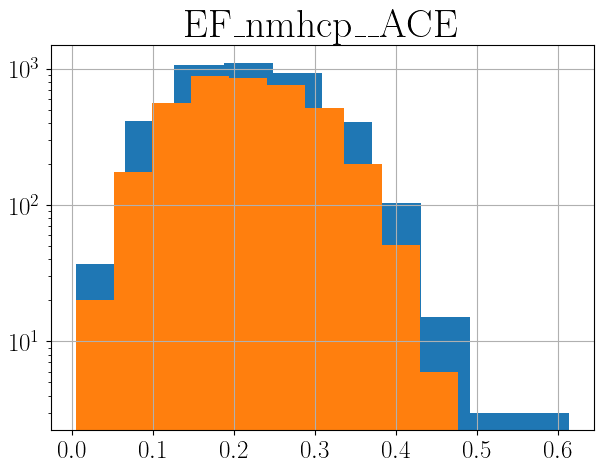

In [80]:
ax = Prediction_Values['ACE', 'P'].hist(f'{target_case}__ACE')
Accepted_Prediction_Values['ACE', 'P'].hist(f'{target_case}__ACE', ax = ax)
ax[0, 0].set_yscale('log')

In [81]:
len(Accepted_Prediction_Values['ACE', 'P'])

4035

In [82]:
colors = {
    'R': 'blue', 
    'M': 'teal', 
    'P': 'red',
    'delta': 'purple'
}

Text(0, 0.5, 'density counts')

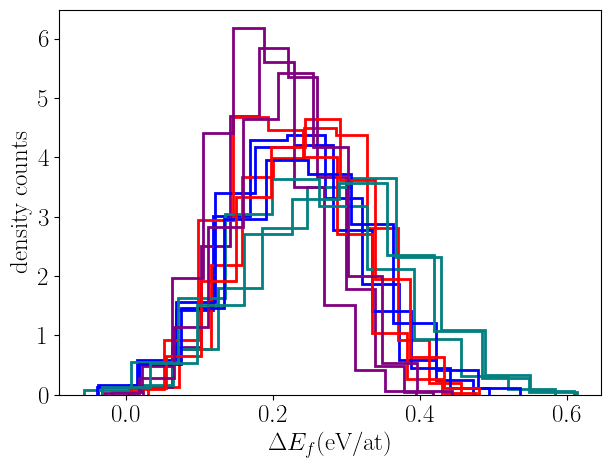

In [83]:
fig, axes = plt.subplots()
for key, serie in Prediction_Values.items():
    axes.hist(Accepted_Prediction_Values[key][f'{target_case}__{key[0]}'], histtype='step', color=colors[key[-1]], linewidth=2, density=True)
axes.set_xlabel(r'$\Delta E_f $(eV/at)')
axes.set_ylabel('density counts')

In [84]:
select_model = '0.7dprojections_0.5os'

In [85]:
coincidence = Prediction_Values[(select_model, 'R')][f'{target_case}__{select_model}'].index.intersection(TRAIN_RBS.index)

In [86]:
difference =TRAIN_RBS.index.difference(coincidence)

In [87]:
TRAIN_RBS.loc[difference]

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv1Mo_sv52.R-ABBBBBBBBBB.NM,bulk R-ABBBBBBBBBB,16.207674 A,-10.574992,238.852230 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,...,1,52,53,0.018868,0.981132,NM,R,0.307309,0.305966,0.304474
Fe_pv52Mo_sv1.R-BAAAAAAAAAA.NM,bulk R-BAAAAAAAAAA,10.590332 A,-8.076915,273.598211 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,...,52,1,53,0.981132,0.018868,NM,R,0.228834,0.159020,0.081452


In [88]:
BS_predict.keys()

dict_keys(['R', 'P', 'delta', 'M'])

In [89]:
labels = {'R': '$R$', 'M': '$M$', 'P': '$P$', 'delta': r'$\delta$'}

In [90]:
Prediction_Values.keys() 

dict_keys([('0.7dprojections_0.5os', 'R'), ('0.7dprojections_0.5os', 'P'), ('0.7dprojections_0.5os', 'delta'), ('0.7dprojections_0.5os', 'M'), ('ACE', 'R'), ('ACE', 'P'), ('ACE', 'delta'), ('ACE', 'M'), ('SOAP', 'R'), ('SOAP', 'P'), ('SOAP', 'delta'), ('SOAP', 'M')])

Text(0.5, 0.01, '$x_{Fe}$')

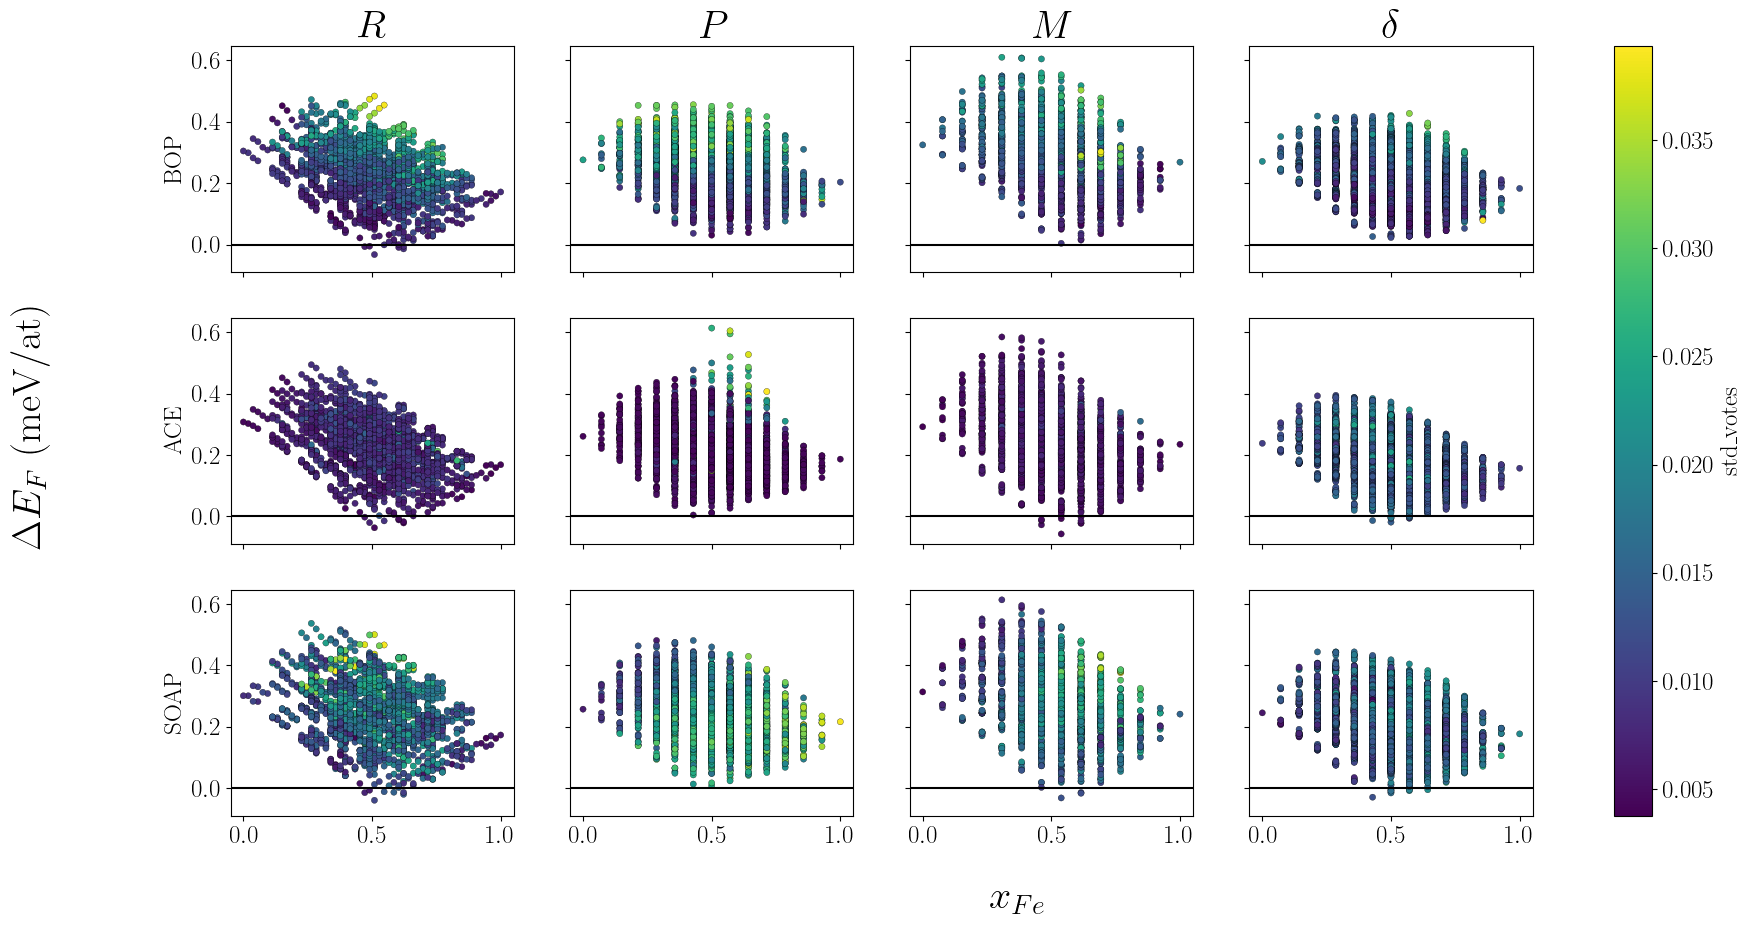

In [91]:
featurename_pos ={'0.7dprojections_0.5os': 0, 'ACE': 1, 'SOAP': 2}
phase_pos = {'R': 0, 'P': 1, 'M': 2, 'delta': 3}
fig, axes = plt.subplots(
    len(FeaturesOfInterest), len(BS_predict),
    figsize = (plt.rcParams['figure.figsize'][0]*3,plt.rcParams['figure.figsize'][1]*2),
    sharey=True, sharex=True)

scatter_mappable = None
for (featurename, phase), prediction in Prediction_Values.items():
    if featurename not in featurename_pos or phase not in phase_pos:
        continue

    I = featurename_pos[featurename]
    J = phase_pos[phase]
    X = BS_predict[phase]['Fe_pv']
    Y = prediction[f'{target_case}__{featurename}']
    stds = prediction['std_votes']

    # Accepted samples: color by voting std.
    intersection = X.index.intersection(Y.index)
    scatter_mappable = axes[I, J].scatter(
        X.loc[intersection], Y.loc[intersection], c=stds, cmap='viridis', s=20, edgecolor='k', linewidth=0.2
        )

    # Multiline panel label in lower-right with larger font for readability.
    if I == 0:
        axes[I, J].set_title(labels[phase])
    if J == 0:
        axes[I, J].set_ylabel(FeatureLabels[ featurename ])
    else:
        axes[I, J].set_ylabel('')
    axes[I, J].axhline(c='k')

if scatter_mappable is not None:
    fig.colorbar(scatter_mappable, ax=axes.ravel().tolist(), label='std_votes')

fig.supylabel(r'$\Delta E_F$ (meV/at)')
fig.supxlabel(r'$x_{Fe}$')

In [92]:
from sklearn.metrics import r2_score, mean_squared_error

In [93]:
from scipy.stats import pearsonr, linregress

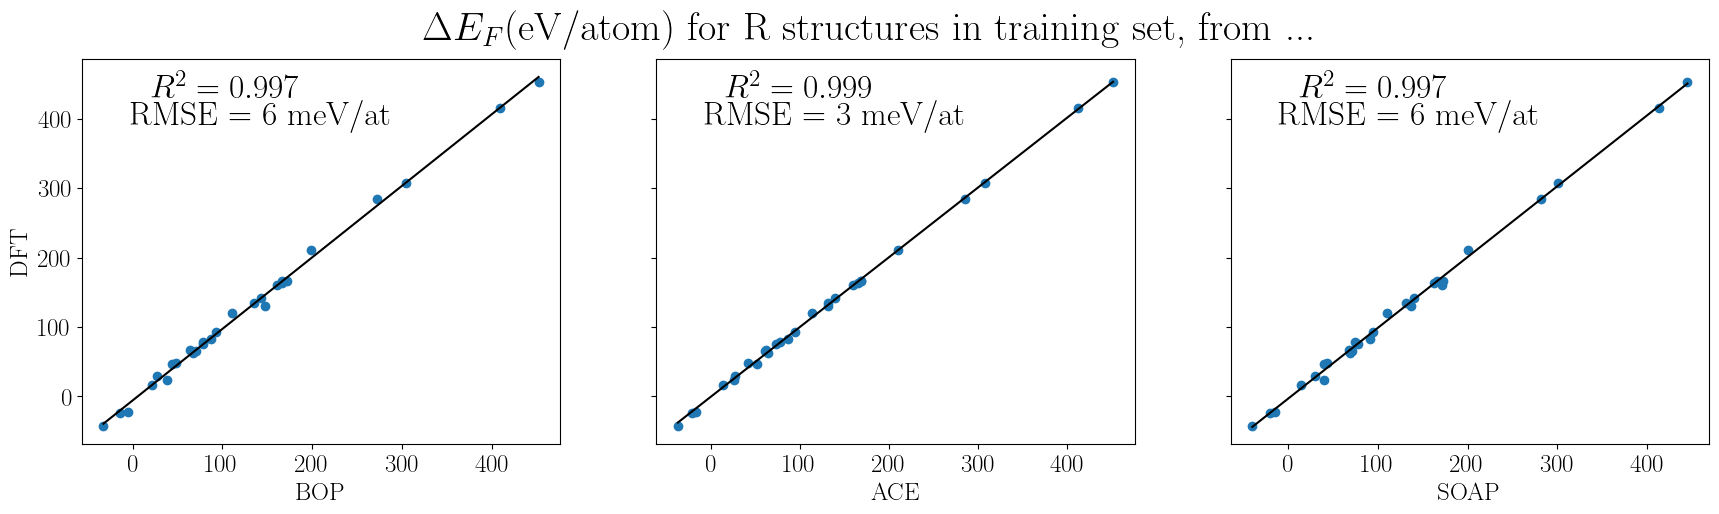

In [94]:
featurename_pos ={'0.7dprojections_0.5os': 0, 'ACE': 1, 'SOAP': 2}
featurename_label ={'0.7dprojections_0.5os': 'BOP', 'ACE': 'ACE', 'SOAP_specific_small': 'SOAP' , 'BOP': 'BOP', 'SOAP': 'SOAP'}
phase_pos = {'R': 0}#, 'R_old': 1, 'P': 2, 'delta': 3, 'M': 4}
fig, axes = plt.subplots(1, len(featurename_pos), figsize=(plt.rcParams['figure.figsize'][0]*len(featurename_pos), plt.rcParams['figure.figsize'][1]), sharey = True)
for (featuregroup, I), ax in zip(featurename_pos.items(), axes):
    test_split_samples = BS.index.intersection(BS_predict['R'].index)
    targetname = f'{target_case}__{featuregroup}'
    if len(test_split_samples) == 0:
        continue
    x = Prediction_Values[(featuregroup, 'R')][targetname][test_split_samples]*1000
    y = BS.loc[test_split_samples][target_case]*1000
    reg = np.polyfit(x, y, 1)
    pol = np.poly1d(reg)
    r2 = r2_score(y, pol(x))
    rmse = mean_squared_error(y, pol(x), squared=False)
    ax.scatter(x, y) 
    ax.plot([x.min(), x.max()], pol([x.min(), x.max()]), 'k')
    ax.annotate (rf'$R^2 = {r2:.3f}$\newline RMSE = {rmse:.0f} meV/at', (0.1, 0.9), xycoords='axes fraction')
    ax.set_xlabel(featurename_label[featurename_label[featuregroup]])
axes[0].set_ylabel('DFT')
fig.suptitle(r'$\Delta E_F $(eV/atom) for R structures in training set, from ...')
fig.savefig(f'Fe-Mo/graphs/Rstructs_Prediction_Vs_DFT_MAG={MAG}.pdf')

In [95]:
BS_predict['P'][BS_predict['P']['Fe_pv'] == 0]

,num_atoms,Fe,Mo,Fe_pv,Mo_sv,Mag,nelem,Structure
Mo_sv56.P-BBBBBBBBBBBB.NM,56,0.0,56.0,0.0,1.0,0,1,11


In [96]:
Prediction_Values.keys()

dict_keys([('0.7dprojections_0.5os', 'R'), ('0.7dprojections_0.5os', 'P'), ('0.7dprojections_0.5os', 'delta'), ('0.7dprojections_0.5os', 'M'), ('ACE', 'R'), ('ACE', 'P'), ('ACE', 'delta'), ('ACE', 'M'), ('SOAP', 'R'), ('SOAP', 'P'), ('SOAP', 'delta'), ('SOAP', 'M')])

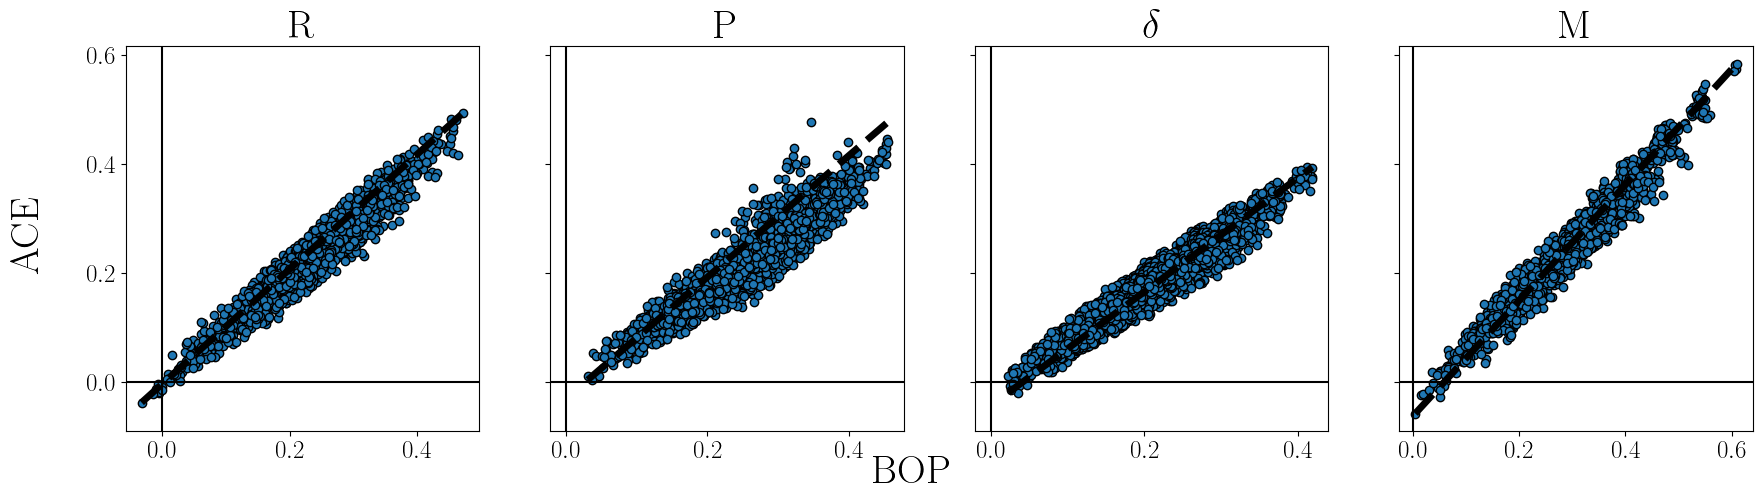

In [97]:
#featurename_pos ={'0.7dprojections_0.5os': 0, 'ACE': 1}
phase_pos = {'R': 0, 'P': 2, 'delta': 3, 'M': 4}#, 'R_old': 1}
phase_label = {'R': 'R', 'P': 'P', 'delta': r'$\delta$', 'M': 'M'}
bopmodel = '0.7dprojections_0.5os'
acemodel = 'ACE'
fig, axes = plt.subplots(
    1, len(phase_pos),
    figsize = (plt.rcParams['figure.figsize'][0]*3,plt.rcParams['figure.figsize'][1]),
    sharey=True)
for phase, axes  in zip(phase_pos, axes):
    if phase == 'R_old':
        continue
    intersection = Accepted_Prediction_Values[(bopmodel, phase)].index.intersection(Accepted_Prediction_Values[(acemodel, phase)].index)
    x = Accepted_Prediction_Values[(bopmodel, phase)][target_case+'__'+bopmodel][intersection]
    y = Accepted_Prediction_Values[(acemodel, phase)][target_case+'__'+acemodel].loc[intersection]
    axes.scatter(x,y,edgecolor='k')
    axes.plot([x.min(), x.max()], [y.min(), y.max()], '--k', lw=5)
    axes.set_title(phase_label[phase])
    axes.axhline(c='k')
    axes.axvline(c='k')

fig.supxlabel('BOP', y=-0.01)
fig.supylabel(acemodel, x=0.07)
fig.savefig(f'Fe-Mo/graphs/Fe-Mo-AcceptedPredictionDifferences_MAG={MAG}.pdf')

# Predicted convex hulls 

In [98]:
from Tools.DatasetTools.Tools import Plotting, PlottingChulls
from scipy.spatial import ConvexHull
from matplotlib.lines import Line2D

In [99]:
for (model, phase), prediction_values in Prediction_Values.items() :
    if (target_case, model) not in BS_predict[phase].columns:
        BS_predict[phase] = pd.concat([BS_predict[phase], prediction_values], axis = 1)

In [100]:
BS_predict.keys()#['R'].filter(regex=target_case)

dict_keys(['R', 'P', 'delta', 'M'])

In [101]:
phasesloc= {'R':0, 'M': 1,'P':2 ,'delta':3}
targetsloc = {target_name: i for i, target_name in enumerate(BS_predict['R'].filter(regex=target_case).columns)}

In [102]:
feature_labels = {'0.7dprojections_0.5os': 'BOP', 'ACE': 'ACE', 'SOAP_specific_small': 'SOAP'}

In [103]:
phase_labels = {'delta': r'$\delta$', 'R': '$R$', 'M': '$M$', 'P': '$P$'}

In [104]:
experimental_range = {
    'sigma': [0.4,0.55],
    'R' : [0.6,0.65],
    'mu' : [0.6, 0.55],
    'lambda': [0.655, 0.66]
}

In [105]:
x = experimental_range['R']

In [106]:
BS_predict[phase].filter(regex='EF_')#columns#['Fe_pv', target_name, 'nelem']

,EF_nmhcp__0.7dprojections_0.5os,EF_nmhcp__ACE,EF_nmhcp__SOAP
Fe_pv52.M-AAAAAAAAAAA.NM,0.268480,0.234651,0.241072
Fe_pv48Mo_sv4.M-AAAAAAAAAAB.NM,0.211189,0.154663,0.161618
Fe_pv48Mo_sv4.M-AAAAAAAAABA.NM,0.179965,0.161854,0.162168
Fe_pv44Mo_sv8.M-AAAAAAAAABB.NM,0.112831,0.089776,0.101356
Fe_pv48Mo_sv4.M-AAAAAAAABAA.NM,0.186264,0.178415,0.191884
...,...,...,...
Fe_pv4Mo_sv48.M-BBBBBBBBABB.NM,0.368833,0.356829,0.390348
Fe_pv8Mo_sv44.M-BBBBBBBBBAA.NM,0.498576,0.461517,0.478757
Fe_pv4Mo_sv48.M-BBBBBBBBBAB.NM,0.406631,0.379126,0.390502
Fe_pv4Mo_sv48.M-BBBBBBBBBBA.NM,0.407141,0.380583,0.399610


In [107]:
P = Plotting()
inchull = {}
opo_chull = {}
CHULLS = {}

for target_name, J in targetsloc.items():
    featurename = target_name.replace(f'{target_case}__', '')
    CHULLS[target_name] = {}

    for phase, I in phasesloc.items():
#        accepted_key = (featurename, phase)
#        if accepted_key not in Accepted_Prediction_Values:
#            continue
#        accepted_predictions = Accepted_Prediction_Values[accepted_key]
#        if target_name not in accepted_predictions.columns:
#            continue

        # Build plottable set from accepted predictions only, plus composition metadata.
        accepted_predictions = Accepted_Prediction_Values[featurename, phase].index
        plottable = pd.concat(
            [
                BS_predict[phase][['Fe_pv', 'nelem']].loc[accepted_predictions],
                Accepted_Prediction_Values[featurename, phase][[target_name]],
            ],
            axis=1,
        ).dropna(axis=0).sort_values(by=['Fe_pv', target_name])

        if len(plottable) < 3:
            continue

        chull = P.get_convex_hulls(
            {phase: plottable}, ['Fe_pv'], getproperty=target_name, viewpoint=(0.0, -100)
        )
        CHULLS[target_name].update(chull)

        all_vertices_low = np.unique(np.hstack(chull[phase].simplices[chull[phase].good]))
        inchull[(phase, target_name)] = plottable.iloc[all_vertices_low].sort_values(by='Fe_pv')

print(f'Generated convex hulls from accepted predictions for {len(CHULLS)} targets and {len(phasesloc)} phases.')

Generated convex hulls from accepted predictions for 3 targets and 4 phases.


In [108]:
ValidationDataLocation = os.path.join(dataset, 'data', 'Validation')

In [109]:
Accepted_Prediction_Values['0.7dprojections_0.5os', 'R']

,EF_nmhcp__0.7dprojections_0.5os,vote_0,vote_1,vote_2,vote_3,vote_4,vote_5,vote_6,vote_7,vote_8,vote_9,vote_10,vote_11,std_votes
Fe_pv19Mo_sv34.R-ABAABABBBBB.NM,0.078392,0.083173,0.073993,0.080873,0.076911,0.071425,0.081684,0.078675,0.078575,0.075517,0.076148,0.084522,0.079212,0.003833
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM,0.452145,0.453380,0.449287,0.446997,0.451909,0.451420,0.452366,0.452498,0.452545,0.449894,0.451887,0.464546,0.449012,0.004326
Fe_pv18Mo_sv35.R-BBBAAABBBBB.NM,0.091141,0.091214,0.093893,0.088017,0.089903,0.091977,0.101755,0.090716,0.088893,0.086577,0.083285,0.093335,0.094131,0.004610
Fe_pv18Mo_sv35.R-BBAABABBBBB.NM,0.092917,0.091615,0.095039,0.086955,0.094341,0.099896,0.082579,0.092340,0.097554,0.096777,0.087094,0.093094,0.097721,0.005162
Fe_pv39Mo_sv14.R-AAAAAAAABBB.NM,0.027232,0.023718,0.028515,0.023860,0.024555,0.024459,0.025605,0.028895,0.022176,0.028394,0.029840,0.041778,0.024987,0.005187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv33Mo_sv20.R-AABBBAAAABA.NM,0.371046,0.393438,0.331022,0.266880,0.377884,0.457482,0.252818,0.302212,0.392067,0.398779,0.316593,0.569797,0.393583,0.087060
Fe_pv23Mo_sv30.R-AABBBBAABAA.NM,0.428172,0.443017,0.362881,0.328023,0.399439,0.457196,0.360210,0.375186,0.463203,0.435508,0.389283,0.669323,0.454795,0.088041
Fe_pv30Mo_sv23.R-BBBBBAAAABA.NM,0.368858,0.401888,0.319141,0.262333,0.373378,0.418639,0.260404,0.328241,0.390176,0.396991,0.305134,0.590444,0.379531,0.088081
Fe_pv41Mo_sv12.R-AABAABAAAAA.NM,0.278043,0.312711,0.216759,0.237496,0.244197,0.225206,0.220631,0.208289,0.332216,0.263564,0.243456,0.526765,0.305223,0.088236


In [110]:
inchull['R', f'{target_case}__0.7dprojections_0.5os' ]

,Fe_pv,nelem,EF_nmhcp__0.7dprojections_0.5os
Mo_sv53.R.NM,0.000000,1,0.304890
Fe_pv19Mo_sv34.R-ABABAABBBBB.NM,0.358491,2,0.057666
Fe_pv27Mo_sv26.R-AAAAAABBBBB.NM,0.509434,2,-0.032404
Fe_pv33Mo_sv20.R-AAAAAAABBBB.NM,0.622642,2,-0.013928
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM,0.849057,2,0.067028
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM,0.886792,2,0.087331
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM,0.962264,2,0.143365
Fe_pv53.R.NM,1.000000,1,0.171438


## save chulls to csv

In [111]:
for (phase, pred__model), chulldata in inchull.items():
    phase_chull_location = os.path.join(ValidationDataLocation, 'inchull', phase)
    os.makedirs(phase_chull_location, exist_ok=True)
    chull_data_loc = os.path.join(phase_chull_location, f'{ pred__model }.csv')
    chulldata.to_csv(chull_data_loc)

## save uncertainties to csv

In [112]:
for (pred__model, phase), predictionvotes in Prediction_Values.items():
    phase_chull_location = os.path.join(ValidationDataLocation, 'inchull', phase)
    os.makedirs(phase_chull_location, exist_ok=True)
    votes_data_loc = os.path.join(phase_chull_location, f'{ pred__model }:votes.csv')
    predictionvotes.to_csv(votes_data_loc)

# Recover samples in convex hull for validation 

In [113]:
ValidationDataLocation = os.path.join(dataset, 'data', 'Validation')

In [114]:
AtomsObjects['P']['Atoms']['atoms']

Fe_pv56.P-AAAAAAAAAAAA.NM           (Atom('Fe', [6.270229734538574, 1.143494556032...
Fe_pv48Mo_sv8.P-AAAAAAAAAAAB.NM     (Atom('Fe', [6.37428511215705, 1.1624710150889...
Fe_pv48Mo_sv8.P-AAAAAAAAAABA.NM     (Atom('Fe', [6.37428511215705, 1.1624710150889...
Fe_pv40Mo_sv16.P-AAAAAAAAAABB.NM    (Atom('Fe', [6.475049825186255, 1.180847359444...
Fe_pv52Mo_sv4.P-AAAAAAAAABAA.NM     (Atom('Fe', [6.322685545287342, 1.153060861664...
                                                          ...                        
Fe_pv4Mo_sv52.P-BBBBBBBBBABB.NM     (Atom('Mo', [6.893805521683064, 1.257215352249...
Fe_pv16Mo_sv40.P-BBBBBBBBBBAA.NM    (Atom('Mo', [6.7599451321235, 1.23280338758266...
Fe_pv8Mo_sv48.P-BBBBBBBBBBAB.NM     (Atom('Mo', [6.849765450381988, 1.249183815301...
Fe_pv8Mo_sv48.P-BBBBBBBBBBBA.NM     (Atom('Mo', [6.849765450381988, 1.249183815301...
Mo_sv56.P-BBBBBBBBBBBB.NM           (Atom('Mo', [6.9372899823230005, 1.26514556312...
Name: atoms, Length: 4096, dtype: object

In [115]:
if not os.path.exists(ValidationDataLocation):
    os.makedirs(ValidationDataLocation)
for (phase, target_name), inchullist in inchull.items():
    group_loc = os.path.join(ValidationDataLocation, 'inchull', phase)
    if not os.path.exists(group_loc):
        os.makedirs(group_loc)
    #inchullist.to_csv(os.path.join(group_loc, 'list.csv'))
    for index, atoms in AtomsObjects[phase]['Atoms']['atoms'][inchullist.index].items():
        validation_atoms_location = os.path.join(group_loc, f'{index}.vasp')
        atoms.write(validation_atoms_location, direct=True, format='vasp')
        validation_structure_location = validation_atoms_location.replace('vasp', 'cfg')
        atoms.write(validation_structure_location, format='cfg')

In [116]:
inchull[('P', f'{target_case}__ACE')]

,Fe_pv,nelem,EF_nmhcp__ACE
Mo_sv56.P-BBBBBBBBBBBB.NM,0.000000,1,0.260740
Fe_pv16Mo_sv40.P-BBABBBBABBAB.NM,0.285714,2,0.070283
Fe_pv20Mo_sv36.P-ABABBBBABBAB.NM,0.357143,2,0.034569
Fe_pv24Mo_sv32.P-AAABBBBABBAB.NM,0.428571,2,0.004406
Fe_pv28Mo_sv28.P-AAABBBBAABAB.NM,0.500000,2,0.011335
Fe_pv32Mo_sv24.P-AAABBBAAABAB.NM,0.571429,2,0.026451
Fe_pv48Mo_sv8.P-AAAABBAAAAAA.NM,0.857143,2,0.092495
Fe_pv52Mo_sv4.P-AAAAABAAAAAA.NM,0.928571,2,0.125969
Fe_pv56.P-AAAAAAAAAAAA.NM,1.000000,1,0.186372


In [117]:
inchull[('R', f'{target_case}__ACE')]

,Fe_pv,nelem,EF_nmhcp__ACE
Mo_sv53.R.NM,0.000000,1,0.307381
Fe_pv21Mo_sv32.R-AAABAABBBBB.NM,0.396226,2,0.026071
Fe_pv27Mo_sv26.R-AAAAAABBBBB.NM,0.509434,2,-0.037114
Fe_pv33Mo_sv20.R-AAAAAAABBBB.NM,0.622642,2,-0.021441
Fe_pv38Mo_sv15.R-BAAAAAAABBB.NM,0.716981,2,0.013287
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM,0.849057,2,0.063679
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM,0.886792,2,0.086116
Fe_pv50Mo_sv3.R-BAAAAAAAABA.NM,0.943396,2,0.124084
Fe_pv53.R.NM,1.000000,1,0.168231


In [118]:
inchull[('delta', f'{target_case}__ACE')]

,Fe_pv,nelem,EF_nmhcp__ACE
Mo_sv56.delta-BBBBBBBBBBBBBB.NM,0.000000,1,0.237916
Fe_pv20Mo_sv36.delta-BBBBBBBBABAAAA.NM,0.357143,2,0.019693
Fe_pv24Mo_sv32.delta-BBBBBBBBAAAAAA.NM,0.428571,2,-0.013554
Fe_pv28Mo_sv28.delta-BBBABBBBAAAAAA.NM,0.500000,2,-0.018909
Fe_pv32Mo_sv24.delta-BBBAABBBAAAAAA.NM,0.571429,2,-0.006263
Fe_pv44Mo_sv12.delta-BBBAAAAAAAAAAA.NM,0.785714,2,0.035350
Fe_pv48Mo_sv8.delta-BABAAAAAAAAAAA.NM,0.857143,2,0.057428
Fe_pv52Mo_sv4.delta-AABAAAAAAAAAAA.NM,0.928571,2,0.094991
Fe_pv56.delta-AAAAAAAAAAAAAA.NM,1.000000,1,0.156751


## Plot predicted CHULL

In [119]:
feature_labels

{'0.7dprojections_0.5os': 'BOP', 'ACE': 'ACE', 'SOAP_specific_small': 'SOAP'}

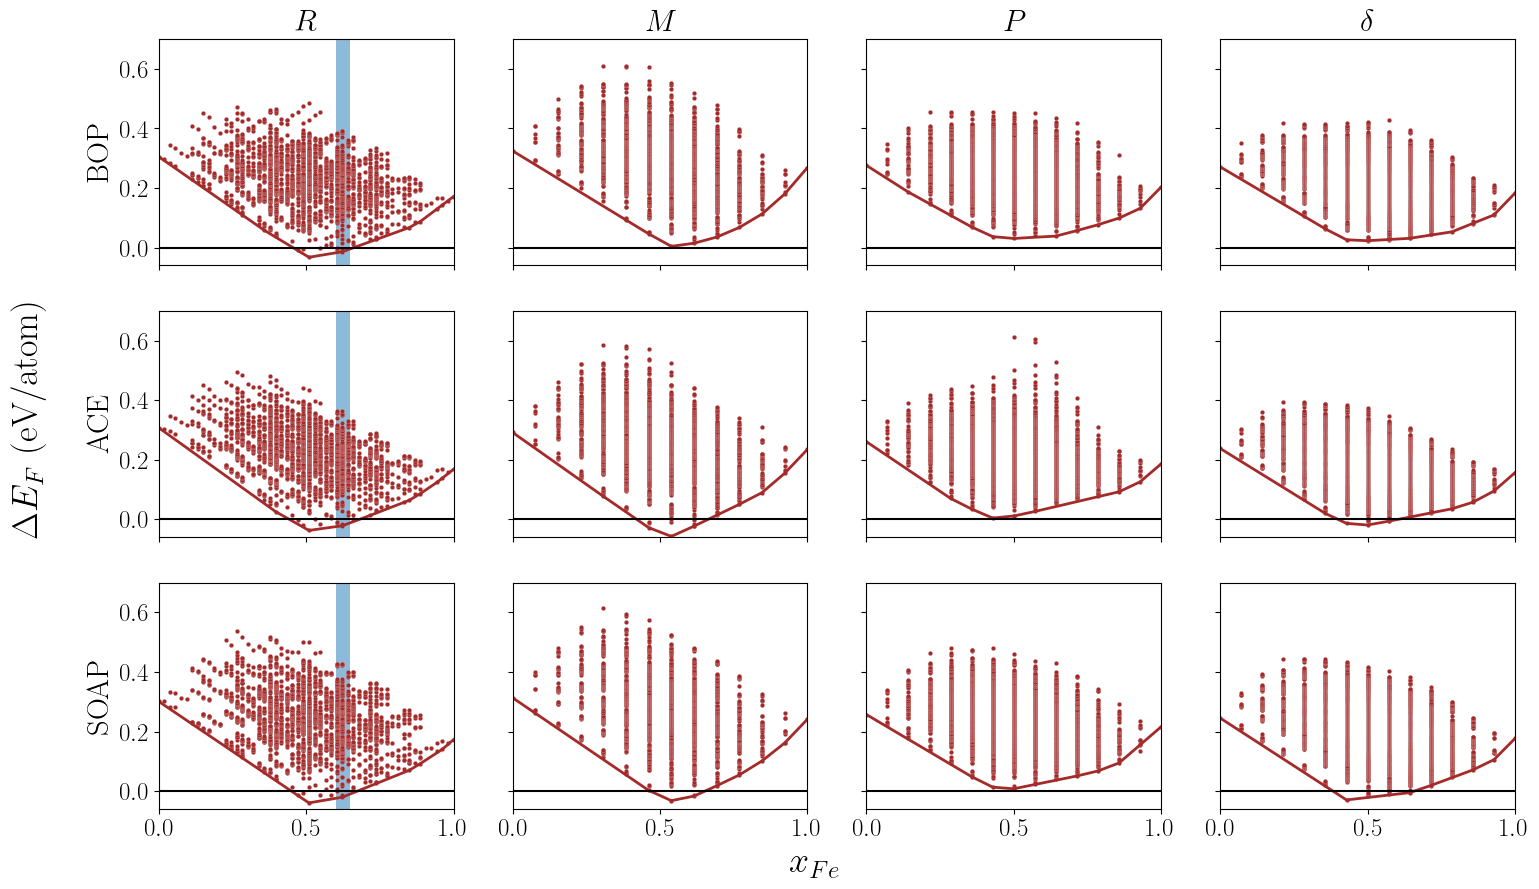

In [120]:
figsize = plt.rcParams['figure.figsize']
fig, axes = plt.subplots(
    len(targetsloc), len(phasesloc),
    sharey=True, sharex=True,
    figsize=(figsize[0] * 2.5, figsize[1] * 2),
)

for target_name, J in targetsloc.items():
    featurename = target_name.replace(target_case + '__', '')
    axes[J, 0].set_ylabel(FeatureLabels[featurename], fontsize=22)

    for phase, I in phasesloc.items():
        plottable = BS_predict[phase][['Fe_pv', target_name, 'nelem']].dropna(axis=0).sort_values(by=['Fe_pv', target_name])

        if phase == 'R':
            axes[J, I].fill_between(experimental_range[phase], -0.1, 0.7, alpha=0.5)

        axes[J, I].scatter(
            plottable['Fe_pv'].values, plottable[target_name].values,
            c='brown', s=10, lw=0.1, edgecolor='w'
        )
        axes[0, I].set_title(phase_labels[phase], fontsize=22)

        l = axes[J, I].plot(
            inchull[(phase, target_name)]['Fe_pv'].values,
            inchull[(phase, target_name)][target_name].values,
            '-', color='brown', label='chull', linewidth=2
        )

        axes[J, I].axhline(c='k')
        axes[J, I].set_ylim([-0.06, 0.7])
        axes[J, I].set_xlim([0, 1])

fig.subplots_adjust(wspace=0.2, hspace=0.2)
fig.supylabel(r'$\Delta E_F$ (eV/atom)', x=0.04, fontsize=26)
fig.supxlabel('$x_{Fe}$', fontsize=26, y=0.04)
fig.savefig(f'Fe-Mo/graphs/Figure_Fe-Mo_compare_predictions_{target_case}.pdf')
fig.savefig(f'Fe-Mo/graphs/Figure_Fe-Mo_compare_predictions_{target_case}.png', dpi=300)

## R chull with uncertainties

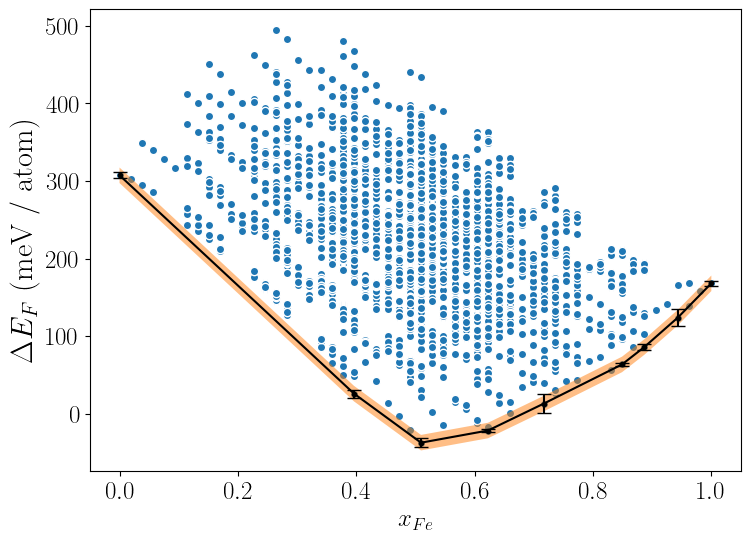

In [121]:
featurename_pos = {'ACE':1}#{'0.7dprojections_0.5os': 0, 'ACE': 1, 'SOAP_specific_small': 2}
featurename_label = {'0.7dprojections_0.5os': 'BOP', 'ACE': 'ACE',  'SOAP_specific_small': 'SOAP'}
test_errors = {'BOP': 0.018, 'ACE':0.010, 'SOAP': 0.015}#?
phase_pos = {'R': 0,} # 'M': 1, 'P': 2, 'delta': 3}#, 'M': 4}
ncols = int(len(phase_pos))
nrows = int(len(featurename_pos))
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(plt.rcParams['figure.figsize'][0]*ncols*1.2,plt.rcParams['figure.figsize'][1]*nrows*1.2),
    sharey=True,
    sharex=True
    )
for featuregroup, I in featurename_pos.items():
    targetname = f'{target_case}__{featuregroup}'
    for phase, J in phase_pos.items():
        training_samples = BS.index.str.contains(f'\\.{phase}-')
        index1 = BS_predict[phase].index
        index2 = Prediction_Values[(featuregroup, phase)].index
        intersection = index1.intersection(index2)
        targetname = f'{target_case}__{featuregroup}'
        this_chull = inchull[(phase, targetname)].index
        axes.scatter(BS_predict[phase]['Fe_pv'][intersection], Prediction_Values[(featuregroup, phase)][targetname][intersection]*1000, label = 'Predictions', edgecolor='w')
        axes.plot(
            BS_predict[phase]['Fe_pv'][this_chull].values,
            Prediction_Values[(featuregroup, phase)][targetname][this_chull].values*1000, 
            'k',
            label = 'convex hull'
            )
        axes.fill_between(
            BS_predict[phase]['Fe_pv'][this_chull].values,
            Prediction_Values[(featuregroup, phase)][targetname][this_chull].values*1000 - test_errors[featuregroup]*1000, 
            Prediction_Values[(featuregroup, phase)][targetname][this_chull].values*1000 + test_errors[featuregroup]*1000, 
            label = 'test error',
            alpha=0.5
            )
        axes.errorbar(
            BS_predict[phase]['Fe_pv'][this_chull].values,
            Prediction_Values[(featuregroup, phase)][targetname][this_chull].values*1000, 
            yerr= Prediction_Values[(featuregroup, phase)]['std_votes'][this_chull].values*1000,
            fmt='.k',
            capsize=5,
#            lolims=True,
            label = 'std from bag of predictions'
            )
        if len(training_samples) <0:
            continue
#        axes.set_title(phase_label[phase], fontsize=22)
#    axes.set_ylabel(featurename_label[featuregroup], fontsize=22)
axes.set_xlabel('$x_{Fe}$')#, fontsize=24)
axes.set_ylabel(rf'$\Delta E_F$ (meV / atom)', fontsize=22)
fig.savefig(f'{dataset}/graphs/{dataset}_R_{targetname}_convexhull.pdf')

## Predicted CHULLs with uncertainties

In [122]:
Prediction_Values.keys()

dict_keys([('0.7dprojections_0.5os', 'R'), ('0.7dprojections_0.5os', 'P'), ('0.7dprojections_0.5os', 'delta'), ('0.7dprojections_0.5os', 'M'), ('ACE', 'R'), ('ACE', 'P'), ('ACE', 'delta'), ('ACE', 'M'), ('SOAP', 'R'), ('SOAP', 'P'), ('SOAP', 'delta'), ('SOAP', 'M')])

In [123]:
test_errors

{'BOP': 0.018, 'ACE': 0.01, 'SOAP': 0.015}

KeyError: 'SOAP'

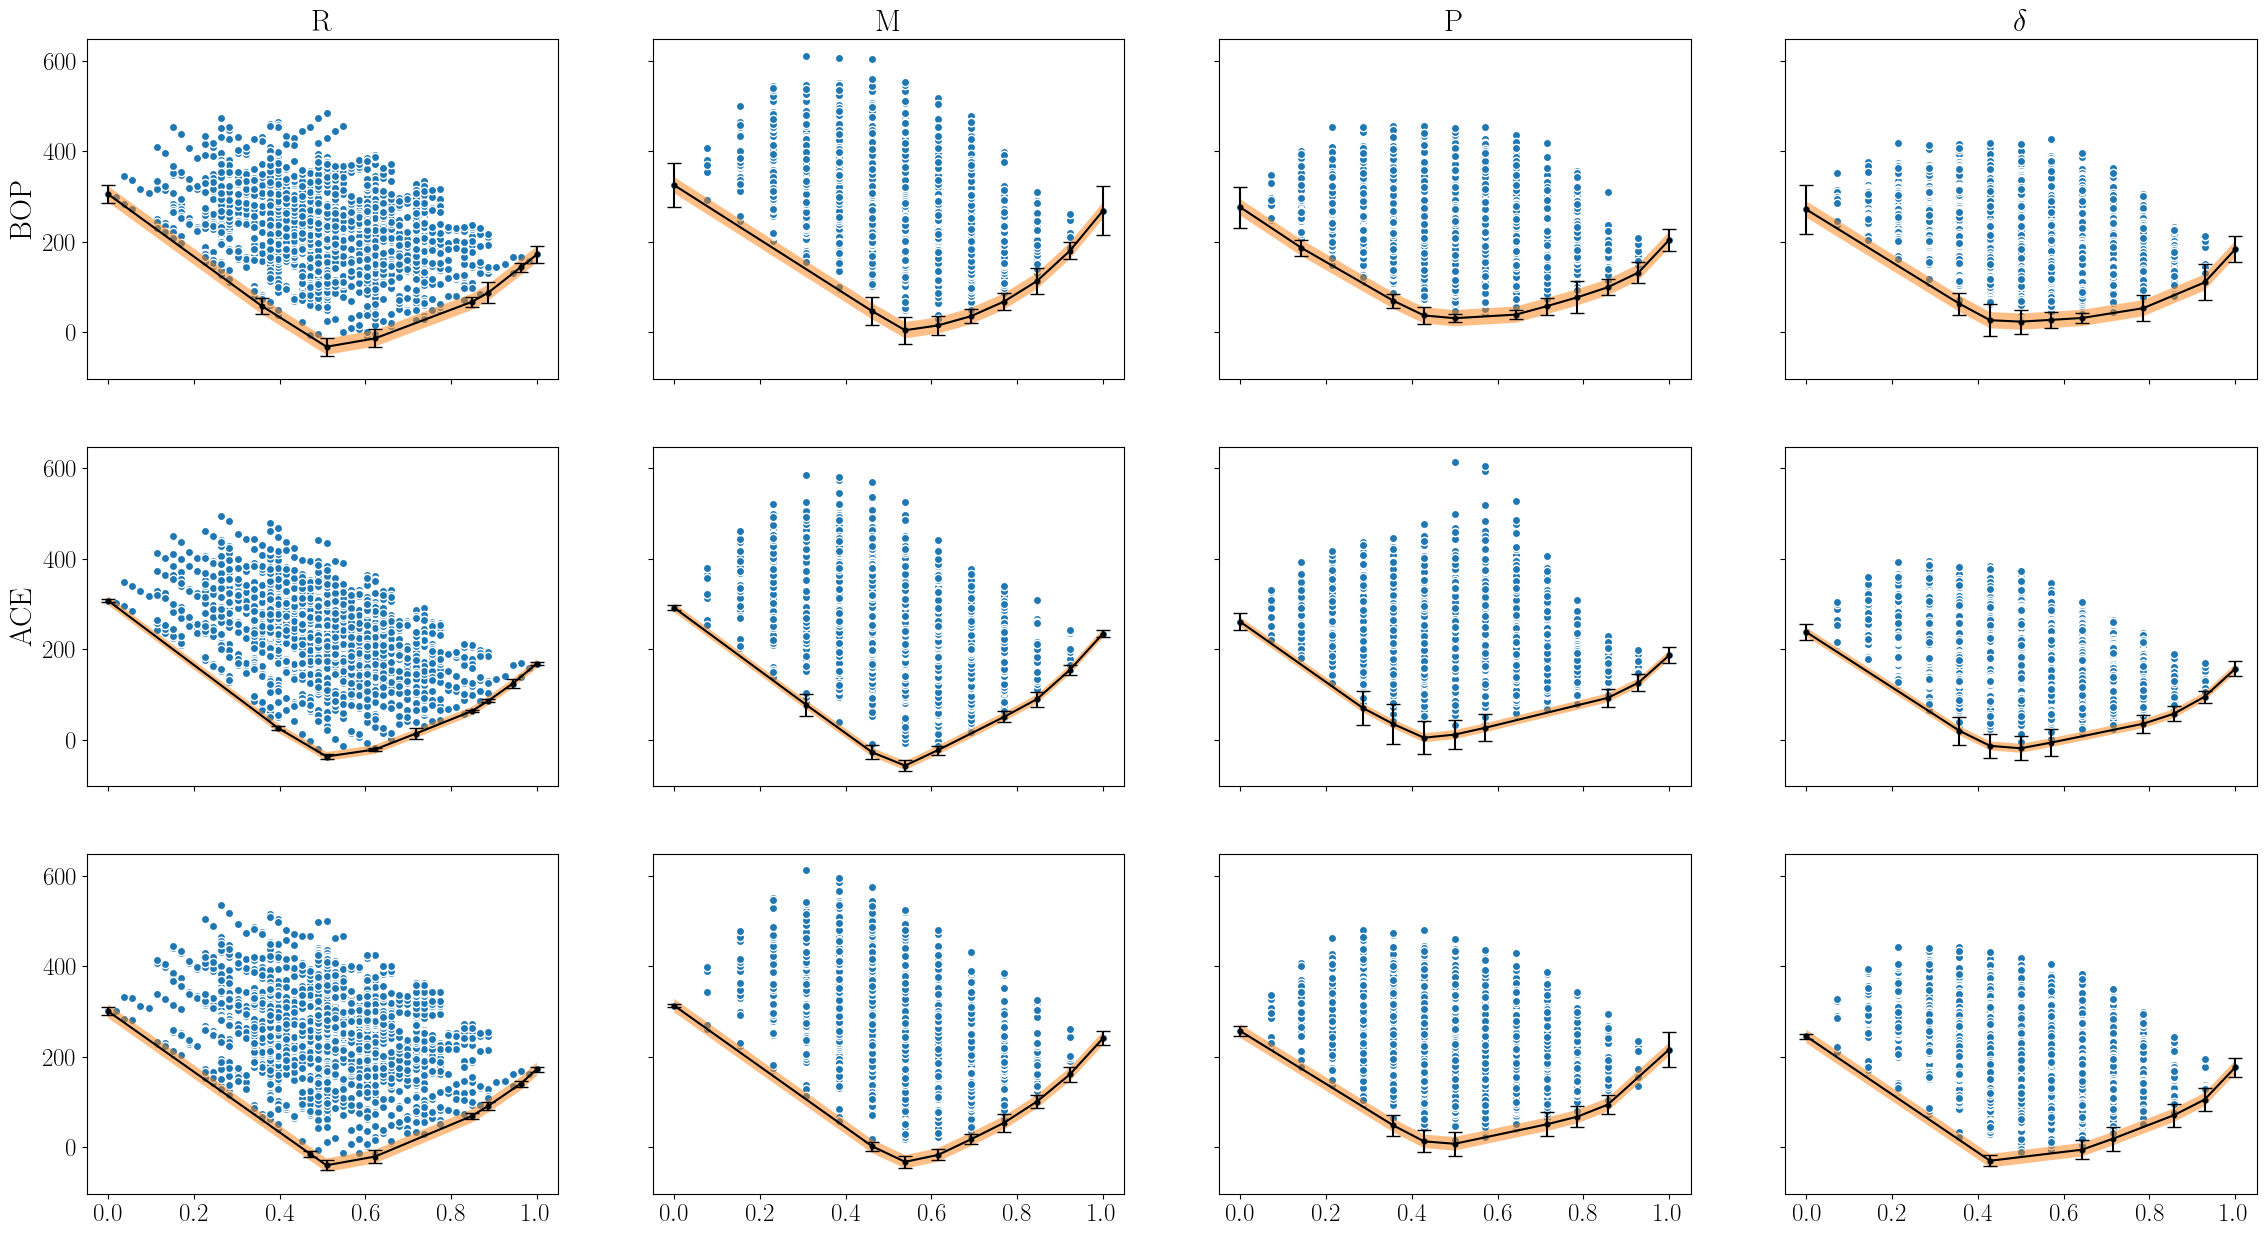

In [124]:
featurename_pos = {'0.7dprojections_0.5os': 0, 'ACE': 1, 'SOAP': 2}
featurename_label = {'0.7dprojections_0.5os': 'BOP', 'ACE': 'ACE',  'SOAP_specific_small': 'SOAP'}
test_errors = {'0.7dprojections_0.5os': 0.018, 'ACE':0.010, 'SOAP': 0.015}#?
featurena_label_inv = {'BOP'}
phase_pos = {'R': 0, 'M': 1, 'P': 2, 'delta': 3}#, 'M': 4}
#fig, axes = plt.subplots(1, len(featurename_pos), figsize=(plt.rcParams['figure.figsize'][0]*2, plt.rcParams['figure.figsize'][1]), sharey = True)
ncols = int(len(phase_pos))
nrows = int(len(featurename_pos))
fig, axes = plt.subplots(nrows, ncols, figsize=(plt.rcParams['figure.figsize'][0]*ncols,plt.rcParams['figure.figsize'][1]*nrows),
sharey=True,
sharex=True)
for featuregroup, I in featurename_pos.items():
    targetname = f'{target_case}__{featuregroup}'
    for phase, J in phase_pos.items():
        training_samples = BS.index.str.contains(f'\\.{phase}-')
        index1 = BS_predict[phase].index
        index2 = Prediction_Values[(featuregroup, phase)].index
        intersection = index1.intersection(index2)
        targetname = f'{target_case}__{featuregroup}'
        this_chull = inchull[(phase, targetname)].index
        axes[I,J].scatter(BS_predict[phase]['Fe_pv'][intersection], Prediction_Values[(featuregroup, phase)][targetname][intersection]*1000, label = 'Predictions', edgecolor='w')
        axes[I,J].plot(
            BS_predict[phase]['Fe_pv'][this_chull].values,
            Prediction_Values[(featuregroup, phase)][targetname][this_chull].values*1000, 
            'k',
            label = 'convex hull'
            )
        axes[I,J].fill_between(
            BS_predict[phase]['Fe_pv'][this_chull].values,
            Prediction_Values[(featuregroup, phase)][targetname][this_chull].values*1000 - test_errors[featuregroup]*1000, 
            Prediction_Values[(featuregroup, phase)][targetname][this_chull].values*1000 + test_errors[featuregroup]*1000, 
            label = 'test error',
            alpha=0.5
            )
        axes[I,J].errorbar(
            BS_predict[phase]['Fe_pv'][this_chull].values,
            Accepted_Prediction_Values[(featuregroup, phase)][targetname][this_chull].values*1000, 
            yerr= Prediction_Values[(featuregroup, phase)]['std_votes'][this_chull].values*1000,
            fmt='.k',
            capsize=5,
#            lolims=True,
            label = 'std from bag of predictions'
            )
        if len(training_samples) <0:
            continue
#        axes[I,J].scatter(
#            BS['Fe_pv'][training_samples],
#            BS[target_case][training_samples]*1000,
#            edgecolor='k',
#            label='DFT calculations',
#            s = 100
#            )
        axes[0, J].set_title(phase_label[phase], fontsize=22)
#    axes[0,I].legend( fontsize=plt.rcParams['font.size']*0.6,bbox_to_anchor = (1, 1),)
    axes[I,0].set_ylabel(featurename_label[featuregroup], fontsize=22)
fig.supxlabel('$x_{Fe}$', fontsize=24, y=0.04)
fig.subplots_adjust(hspace=0.1, wspace=0.1)
fig.supylabel(r'$\Delta E_F$ (meV / atom)', fontsize=22, x=0.075)
fig.savefig(f'{dataset}/graphs/{dataset}_R_{targetname}_convexhull.pdf')
#fig.supxlabel('$x_{Fe}$', y=-0.01)
#fig.supylabel (r'$\Delta E_F$ (meV / atom)')
#fig.legend([Line2D([0],[0], ))])

In [ ]:
BOP_vs_ACE = (Prediction_Values[(bopmodel, 'R')][f'{target_case}__{bopmodel}'] - Prediction_Values[(acemodel, 'R')][f'{target_case}__{acemodel}']).abs()

## difference as function to distance to the hull

In [ ]:
from scipy.spatial import Delaunay

In [ ]:
xp = inchull[('R',f'{target_case}__{acemodel}')]['Fe_pv']
yp = inchull[('R',f'{target_case}__{acemodel}')][f'{target_case}__{acemodel}']

In [ ]:
import pdb

In [ ]:
def distance_to_chull(x, y,  chull_def: pd.core.series.Series, valuename : str):
    y_in_chull = np.interp(x, xp, yp,)
    return y - y_in_chull

In [ ]:
targetname=f'{target_case}__ACE'
distance_to_chull(BS_predict['R']['Fe_pv']['Fe_pv53.R.NM'], Prediction_Values[(acemodel, 'R')][targetname]['Fe_pv53.R.NM'], inchull[('R',f'{target_case}__{acemodel}')], f'{target_case}__{acemodel}' )

0.0

In [ ]:
xy = pd.concat([BS_predict['R']['Fe_pv'], Prediction_Values[(acemodel, 'R')][targetname]], axis = 1)

In [ ]:
inchull['R', f'{target_case}__{acemodel}' ]

,Fe_pv,nelem,EF_nmhcp__ACE
Mo_sv53.R.NM,0.000000,1,0.307381
Fe_pv21Mo_sv32.R-AAABAABBBBB.NM,0.396226,2,0.026071
Fe_pv27Mo_sv26.R-AAAAAABBBBB.NM,0.509434,2,-0.037114
Fe_pv33Mo_sv20.R-AAAAAAABBBB.NM,0.622642,2,-0.021441
Fe_pv38Mo_sv15.R-BAAAAAAABBB.NM,0.716981,2,0.013287
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM,0.849057,2,0.063679
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM,0.886792,2,0.086116
Fe_pv50Mo_sv3.R-BAAAAAAAABA.NM,0.943396,2,0.124084
Fe_pv53.R.NM,1.000000,1,0.168231


In [ ]:
inchull['R', f'{target_case}__{acemodel}']

,Fe_pv,nelem,EF_nmhcp__ACE
Mo_sv53.R.NM,0.000000,1,0.307381
Fe_pv21Mo_sv32.R-AAABAABBBBB.NM,0.396226,2,0.026071
Fe_pv27Mo_sv26.R-AAAAAABBBBB.NM,0.509434,2,-0.037114
Fe_pv33Mo_sv20.R-AAAAAAABBBB.NM,0.622642,2,-0.021441
Fe_pv38Mo_sv15.R-BAAAAAAABBB.NM,0.716981,2,0.013287
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM,0.849057,2,0.063679
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM,0.886792,2,0.086116
Fe_pv50Mo_sv3.R-BAAAAAAAABA.NM,0.943396,2,0.124084
Fe_pv53.R.NM,1.000000,1,0.168231


In [ ]:
compound = xy.iloc[0]

In [ ]:
distances_to_chull = {} # pd.Series([], name = 'DistanceToChull')
for index, compound in xy.iterrows():
    distances_to_chull[index] = distance_to_chull(compound['Fe_pv'], compound[targetname], inchull[('R', f'{target_case}__{acemodel}')], targetname)
distances_to_chull = pd.Series(distances_to_chull)

In [ ]:
selection = xy.index.str.contains('NM')

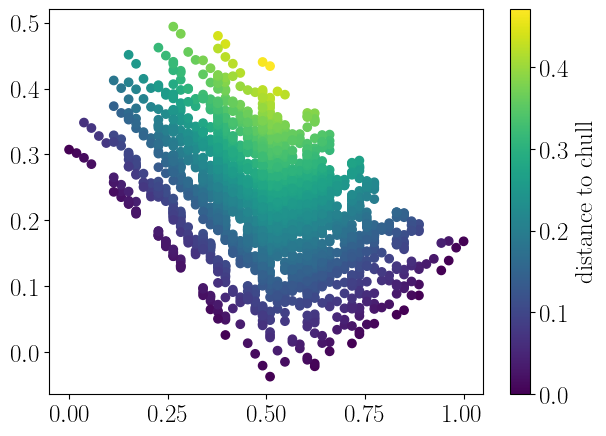

In [ ]:
plt.scatter(xy['Fe_pv'][selection], xy[targetname][selection], c=distances_to_chull[selection])
plt.colorbar(label='distance to chull')

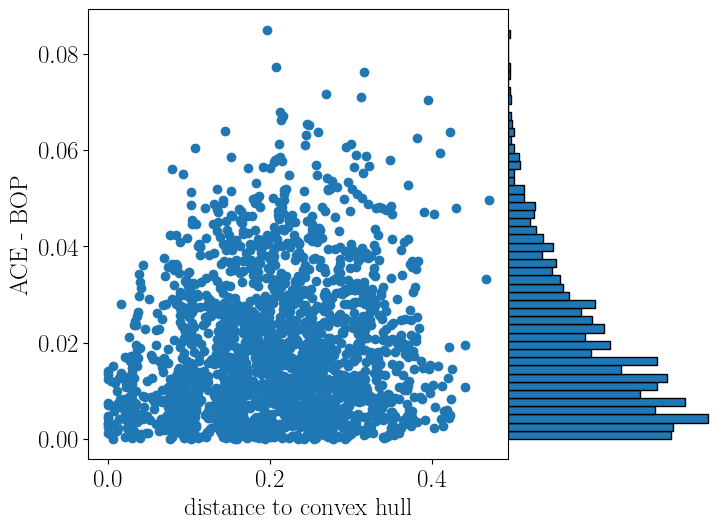

In [ ]:
fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 0.6, 0.9])
ax2 = fig.add_axes([0.7, 0.1, 0.3,0.9], sharey = axes)
ax2.set_axis_off()
axes.scatter(distances_to_chull[selection], BOP_vs_ACE[selection])
hist = ax2.hist(BOP_vs_ACE[selection], orientation='horizontal', bins = 50,edgecolor='k')
axes.set_xlabel ('distance to convex hull')
axes.set_ylabel('ACE - BOP')
fig.savefig(f'{dataset}/graphs/{dataset}_error_vs_distance_to_chull.pdf')

Text(0.5, 1.0, 'Kernel Ridge / EF_nmhcp__ACE')

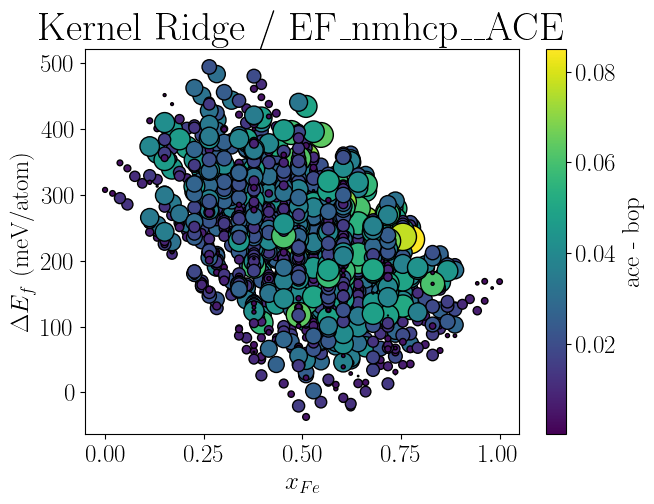

In [ ]:
fig, axes = plt.subplots()
mapble = axes.scatter(xy['Fe_pv'], xy[targetname]*1000, c=BOP_vs_ACE, s=BOP_vs_ACE*5000, edgecolor='k')#c=distances_to_chull)
plt.colorbar(label='ace - bop', mappable=mapble)
axes.set_xlabel(r'$x_{Fe}$')
axes.set_ylabel(r'$\Delta E_f$ (meV/atom)')
axes.set_title(ModelName+' / '+targetname)

# Recover samples in convex hull for validation 

In [ ]:
ValidationDataLocation = os.path.join(dataset, 'data', 'Validation')

In [ ]:
ValidationDataLocation

'Fe-Mo/data/Validation'

In [ ]:
pd.concat(inchull, axis =0).to_csv(os.path.join(ValidationDataLocation, f'inchull__{target_case}.csv'))

In [ ]:
if not os.path.exists(ValidationDataLocation):
    os.makedirs(ValidationDataLocation)
for (phase, target_name), inchullist in inchull.items():
    group_loc = os.path.join(ValidationDataLocation, f'inchull', phase, target_name)
    if not os.path.exists(group_loc):
        os.makedirs(group_loc)
    #inchullist.to_csv(os.path.join(group_loc, 'list.csv'))
    for index, atoms in AtomsObjects[phase]['Atoms']['atoms'][inchullist.index].items():
        validation_atoms_location = os.path.join(group_loc, f'{index}.vasp')
        atoms.write(validation_atoms_location, direct=True, format='vasp')
        validation_structure_location = validation_atoms_location.replace('vasp', 'cfg')
        atoms.write(validation_structure_location, format='cfg')

In [ ]:
inchull[('delta', f'{target_case}__ACE')]


,Fe_pv,nelem,EF_nmhcp__ACE
Mo_sv56.delta-BBBBBBBBBBBBBB.NM,0.000000,1,0.237916
Fe_pv20Mo_sv36.delta-BBBBBBBBABAAAA.NM,0.357143,2,0.019693
Fe_pv24Mo_sv32.delta-BBBBBBBBAAAAAA.NM,0.428571,2,-0.013554
Fe_pv28Mo_sv28.delta-BBBABBBBAAAAAA.NM,0.500000,2,-0.018909
Fe_pv32Mo_sv24.delta-BBBAABBBAAAAAA.NM,0.571429,2,-0.006263
Fe_pv44Mo_sv12.delta-BBBAAAAAAAAAAA.NM,0.785714,2,0.035350
Fe_pv48Mo_sv8.delta-BABAAAAAAAAAAA.NM,0.857143,2,0.057428
Fe_pv52Mo_sv4.delta-AABAAAAAAAAAAA.NM,0.928571,2,0.094991
Fe_pv56.delta-AAAAAAAAAAAAAA.NM,1.000000,1,0.156751


In [ ]:
for (phase, target_name), inchullist in opo_chull.items():
    group_loc = os.path.join(ValidationDataLocation, f'opochull', phase, target_name)
    if not os.path.exists(group_loc):
        os.makedirs(group_loc)
    inchullist.to_csv(os.path.join(group_loc, 'list.csv'))
    for index, atoms in AtomsObjects[phase]['atoms'][inchullist.index].items():
        validation_atoms_location = os.path.join(group_loc, f'{index}.vasp')
        atoms.write(validation_atoms_location, format='vasp',sort=True)


In [ ]:
inchull[('R',f'{target_case}__0.7dprojections_0.5os' )].shape

(8, 3)

In [ ]:
AtomsObjects[phase]['Atoms']['atoms'][inchullist.index]

Mo_sv56.delta-BBBBBBBBBBBBBB.NM           (Atom('Mo', [1.7119784720347544, 4.69216107593...
Fe_pv24Mo_sv32.delta-BBBBBBBBAAAAAA.NM    (Atom('Mo', [1.645442447939846, 4.509800288397...
Fe_pv36Mo_sv20.delta-BBBAABBAAAAAAA.NM    (Atom('Mo', [1.6100554815164523, 4.41281230101...
Fe_pv40Mo_sv16.delta-BBAAABBAAAAAAA.NM    (Atom('Mo', [1.5979072424992284, 4.37951661699...
Fe_pv48Mo_sv8.delta-AABBAAAAAAAAAA.NM     (Atom('Fe', [1.5730406130392627, 4.31136258775...
Fe_pv52Mo_sv4.delta-AABAAAAAAAAAAA.NM     (Atom('Fe', [1.5603069161817937, 4.27646229097...
Fe_pv56.delta-AAAAAAAAAAAAAA.NM           (Atom('Fe', [1.5473619161942118, 4.24098285822...
Name: atoms, dtype: object